# Discovering Plate Approach Patterns Among Major League Baseball (MLB) Batters Through Data Mining

## Sections
1. Data Inspection & Preprocessing
2. Univariate Analysis
3. Bivariate & Multivariate Analysis
4. Feature Engineering & Selection
5. Data Transformation
6. Clustering
7. Anomaly Detection

# Data Inspection & Preprocessing

## Dataset Overview

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/mlb_data.csv")
df.head()

,"last_name, first_name",player_id,year,k_percent,bb_percent,woba,xwoba,z_swing_percent,oz_swing_percent,oz_contact_percent,iz_contact_percent,swing_percent
0,"Cabrera, Miguel",408234,2021,22.4,7.6,0.305,0.313,69.1,30.2,57.1,82.0,49.4
1,"Cruz, Nelson",443558,2021,21.6,8.7,0.346,0.367,73.8,31.0,52.6,77.3,51.0
2,"Peralta, David",444482,2021,17.1,8.6,0.314,0.294,66.3,27.4,59.9,86.8,46.5
3,"Blackmon, Charlie",453568,2021,15.6,9.3,0.333,0.358,67.9,26.2,63.9,85.8,47.3
4,"McCutchen, Andrew",457705,2021,23.0,14.1,0.335,0.340,63.7,19.1,50.5,81.1,41.7


The dataset contains MLB player plate approach and performance statistics, where each row represents a player-season observation.

In [2]:
# Data shape and types
print(df.shape)
df.info()

(669, 12)
<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   last_name, first_name  669 non-null    str    
 1   player_id              669 non-null    int64  
 2   year                   669 non-null    int64  
 3   k_percent              669 non-null    float64
 4   bb_percent             669 non-null    float64
 5   woba                   669 non-null    float64
 6   xwoba                  669 non-null    float64
 7   z_swing_percent        669 non-null    float64
 8   oz_swing_percent       669 non-null    float64
 9   oz_contact_percent     669 non-null    float64
 10  iz_contact_percent     669 non-null    float64
 11  swing_percent          669 non-null    float64
dtypes: float64(9), int64(2), str(1)
memory usage: 62.8 KB


The dataset holds 669 observations and 12 attributes. The forthcoming analysis will focus on the nine numerical features relevant to plate approach and performance.

## Data Quality Checks

In [3]:
# Missing Values
df.isna().sum()

last_name, first_name    0
player_id                0
year                     0
k_percent                0
bb_percent               0
woba                     0
xwoba                    0
z_swing_percent          0
oz_swing_percent         0
oz_contact_percent       0
iz_contact_percent       0
swing_percent            0
dtype: int64

In [4]:
# Duplicates
df.duplicated().sum()

np.int64(0)

There are no missing values or duplicated rows in the dataset, so no data cleaning is required.

## Summary Statistics

In [5]:
# Basic summary statistics
df.iloc[:,3:].describe()

,k_percent,bb_percent,woba,xwoba,z_swing_percent,oz_swing_percent,oz_contact_percent,iz_contact_percent,swing_percent
count,669.000000,669.000000,669.000000,669.000000,669.000000,669.000000,669.000000,669.000000,669.000000
mean,20.597010,8.901046,0.333913,0.335398,67.735277,28.061883,58.447683,83.546039,47.503438
std,5.397645,2.912972,0.031473,0.032173,5.704530,5.770397,9.215808,4.968837,4.705122
min,3.100000,2.500000,0.245000,0.265000,52.800000,12.200000,35.500000,69.400000,35.000000
25%,16.700000,6.800000,0.314000,0.315000,63.800000,23.900000,51.600000,80.100000,44.300000
50%,20.500000,8.800000,0.332000,0.332000,67.500000,27.500000,58.600000,83.600000,47.400000
75%,24.500000,10.700000,0.351000,0.352000,71.500000,31.600000,63.900000,86.900000,50.400000
max,34.600000,22.200000,0.476000,0.480000,83.600000,47.500000,92.300000,96.100000,62.300000


Summary statistics show reasonable ranges and no glaring errors. Further insights will be explored through univariate analysis.

# Univariate Analysis

All features generally exhibit unimodal distributions with varying degrees of skew and dispersion. Key differences emerge in swing aggression, contact ability, and discipline metrics.

In [6]:
# Method to plot histogram and boxplot
def plot_feature(df, column, label):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    sns.histplot(df[column], bins=25, kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {label}")
    axes[0].set_xlabel(label)
    
    # Boxplot
    sns.boxplot(x=df[column], ax=axes[1])
    axes[1].set_title(f"{label} Boxplot")
    axes[1].set_xlabel(label)
    
    # Show plots side-by-side
    plt.tight_layout()
    plt.show()

## Feature Distributions Overview

### Swing%

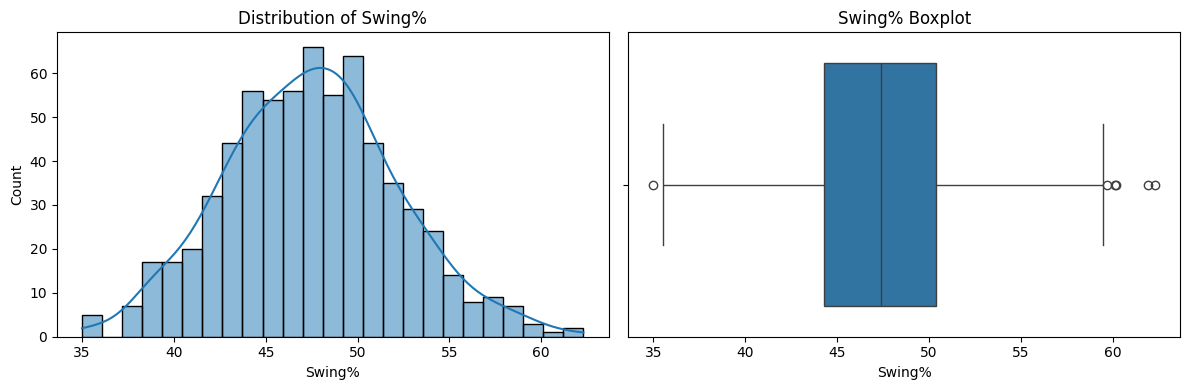

In [7]:
# Build and show histogram and boxplot
plot_feature(df, "swing_percent", "Swing%")

Swing% displays a roughly symmetric distribution with moderate spread and some high-end outliers. This suggests that extreme aggression is more common than extreme passivity, making Swing% useful for distinguishing between aggressive and selective hitters.

### Z-Swing%

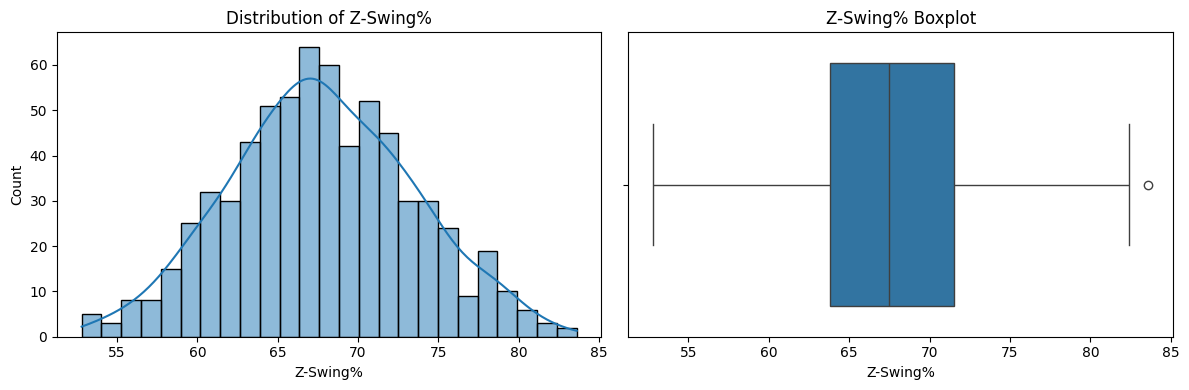

In [8]:
# Build and show histogram and boxplot
plot_feature(df, "z_swing_percent", "Z-Swing%")


Z-Swing% is unimodal with moderate variability and a tight central cluster around the mean. This indicates relatively consistent in-zone behavior across players, with some variation that helps differentiate levels of in-zone aggression.

### O-Swing%

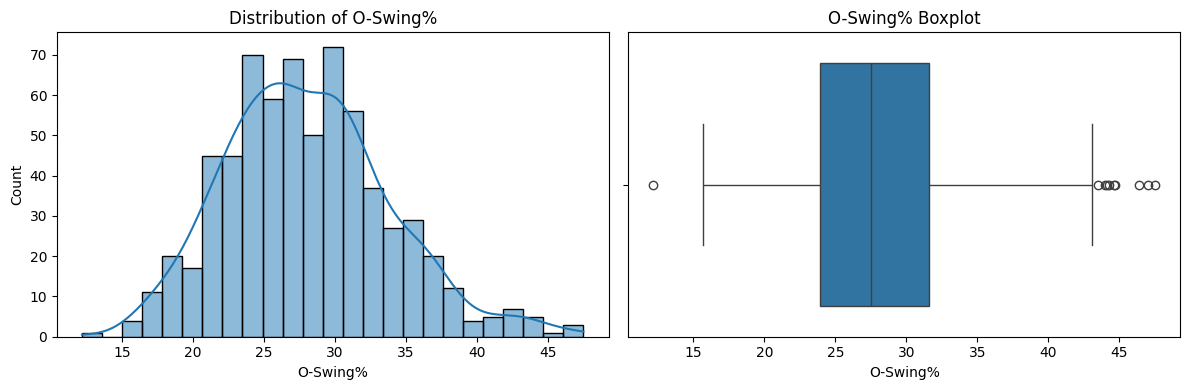

In [9]:
# Build and show histogram and boxplot
plot_feature(df, "oz_swing_percent", "O-Swing%")

O-Swing% shows a right-skewed distribution with several high-end outliers. While most players fall within a central range, a subset exhibits elevated chase rates, making this a strong indicator of aggressive versus disciplined plate approaches.

### Z-Contact%

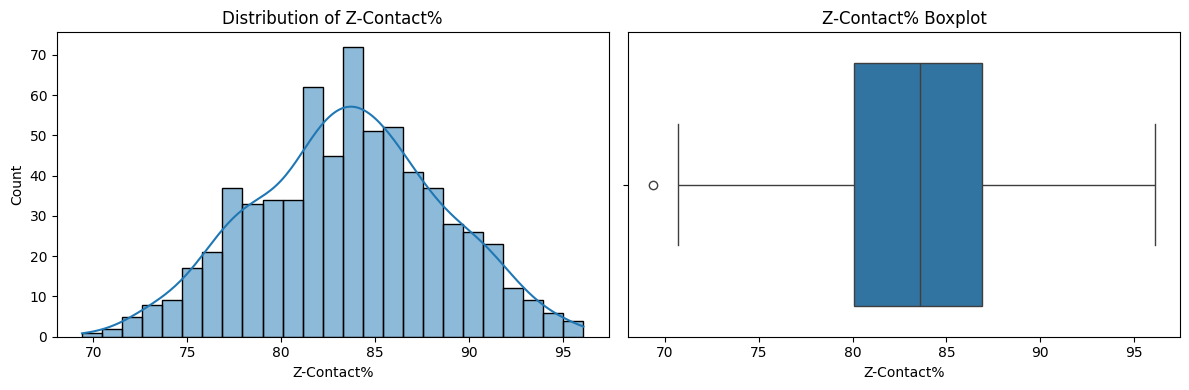

In [10]:
# Build and show histogram and boxplot
plot_feature(df, "iz_contact_percent", "Z-Contact%")

Z-Contact% has moderate variability with a slight left skew in its unimodal distribution, indicating that higher contact rates are more common. Differences in spread highlight variation in bat-to-ball skill on pitches within the strike zone.

### O-Contact%

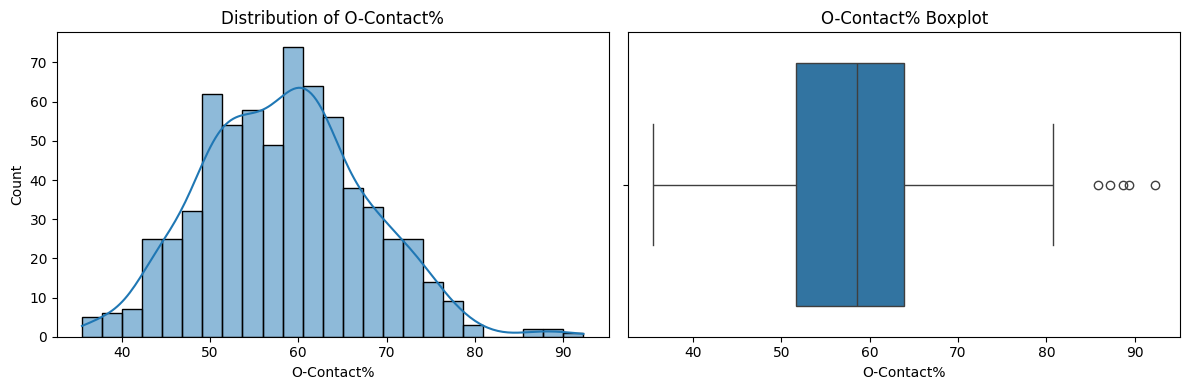

In [11]:
# Build and show histogram and boxplot
plot_feature(df, "oz_contact_percent", "O-Contact%")

O-Contact% holds greater variability than Z-Contact% and a right-skewed distribution. This reflects significant differences in contact ability on pitches outside the zone, making it useful for identifying extremes in plate discipline and bat-to-ball skill.

### wOBA

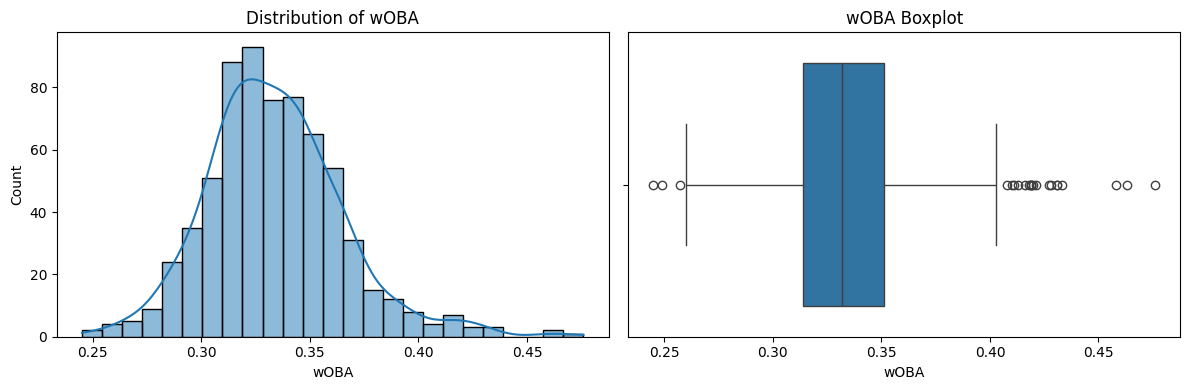

In [12]:
# Build and show histogram and boxplot
plot_feature(df, "woba", "wOBA")

wOBA is tightly clustered with limited variability but includes several upper-tail outliers, producing a slight right skew. This indicates that while most players perform similarly, a subset achieves notably higher offensive outcomes. wOBA will be used to evaluate cluster performance rather than in the clustering process itself.

### xwOBA

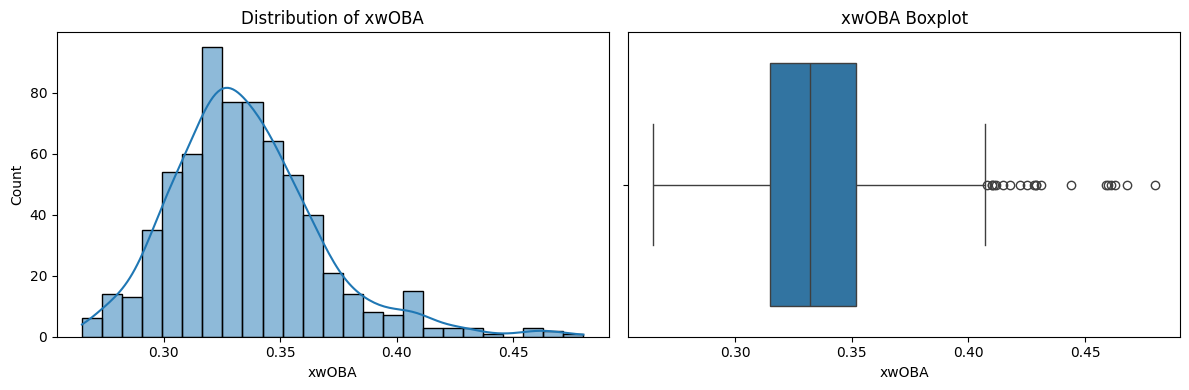

In [13]:
# Build and show histogram and boxplot
plot_feature(df, "xwoba", "xwOBA")


xwOBA closely mirrors the distribution of wOBA but is slightly more concentrated and features more high-end outliers. This suggests the presence of players whose expected performance exceeds observed outcomes, making xwOBA useful for evaluating underlying and over/underperformance across clusters.

### BB%

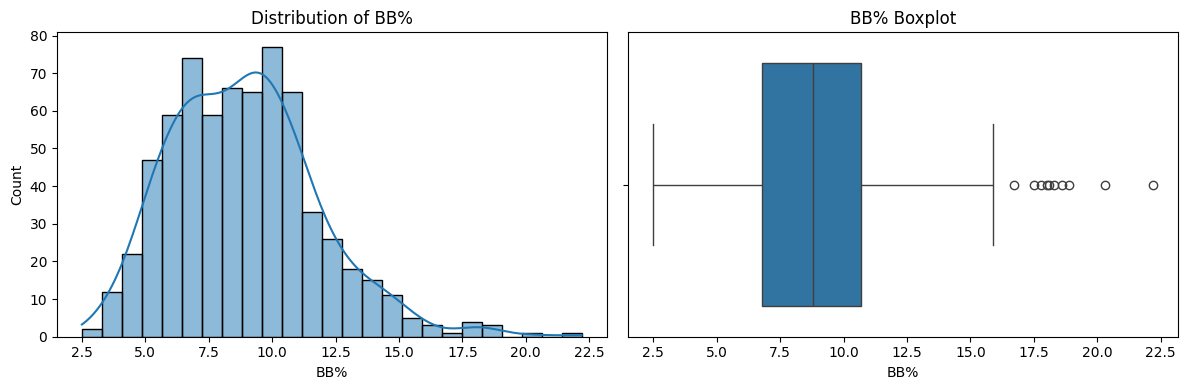

In [14]:
# Build and show histogram and boxplot
plot_feature(df, "bb_percent", "BB%")

BB% follows a right-skewed unimodal distribution with several high-end outliers. Most players fall within a central range, while a small group demonstrates exceptional walk rates, showing strong plate discipline.

### K%

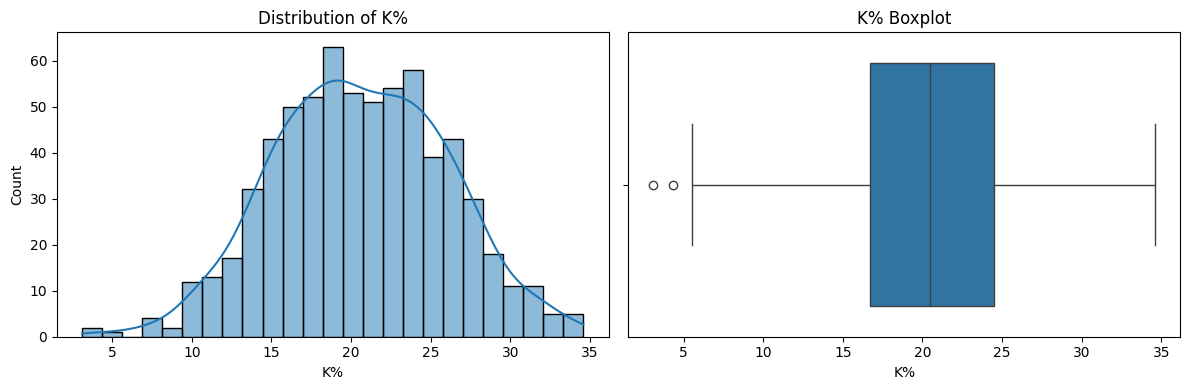

In [15]:
# Build and show histogram and boxplot
plot_feature(df, "k_percent", "K%")

K% exhibits a relatively symmetric distribution with a wide range of values. This variation highlights meaningful differences in strikeout tendencies, making it a useful feature for distinguishing player approaches.

## Impact

Overall, the features show meaningful variation in swing behavior, contact ability, and discipline. While individual distributions provide useful context, their relationships will be more impactful when analyzed together. Bivariate and multivariate analysis will further reveal how these metrics interact to form distinct batter profiles.

# Bivariate & Multivariate Analysis

Bivariate and multivariate analysis are used to reveal feature relationships and examine the essential ones for cluster creation.

## Correlation Heatmap

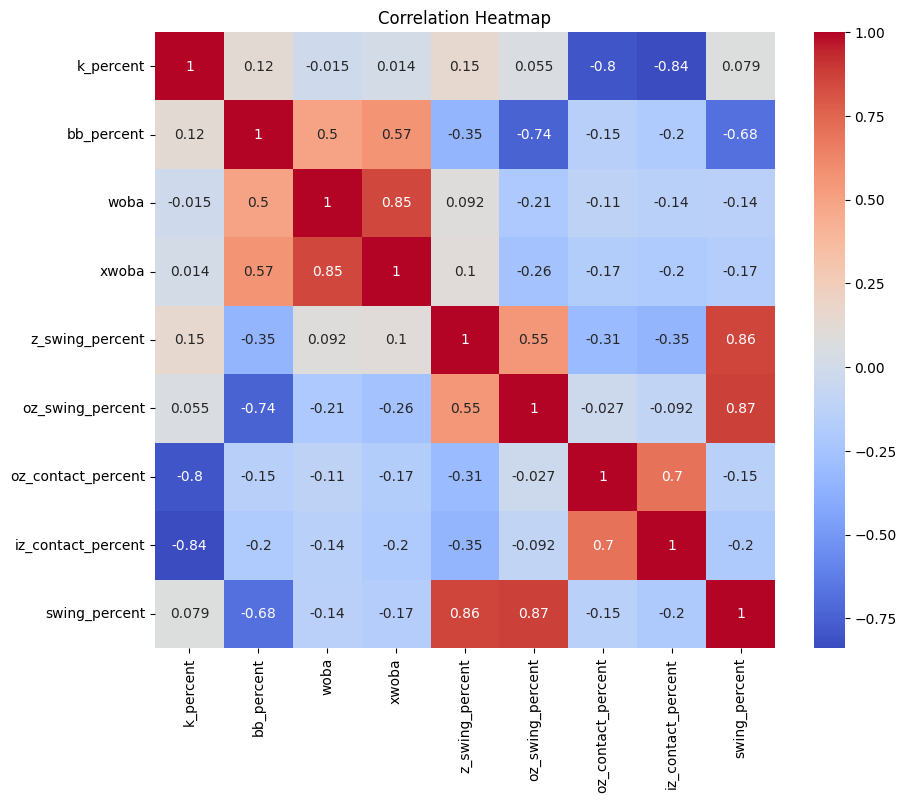

In [16]:
# Build and show correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.iloc[:, 3:].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap reflects a variety of relationships across features. There are more inverse relationships, and the strongest ones appear among swing, contact, and strikeout rates. The relationships indicate that individual features gain more meaning when analyzed together, heavily guiding feature selection.

## Key Feature Scatterplot Relationships

In [17]:
# Method to build and show scatterplots
def scatter_plot(df, x, y, title):
    df.plot.scatter(x=x, y=y)
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

### Swing% vs. Z-Swing% & O-Swing%

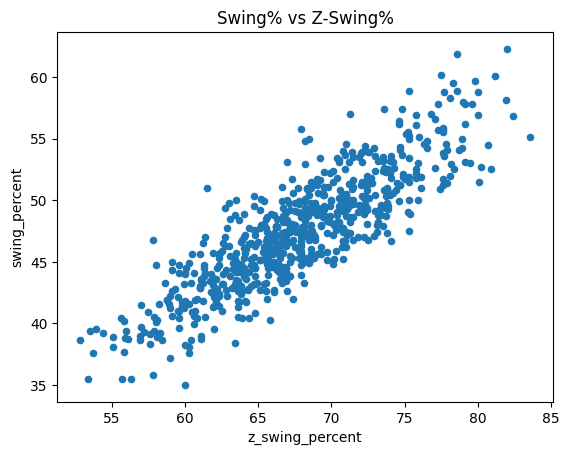

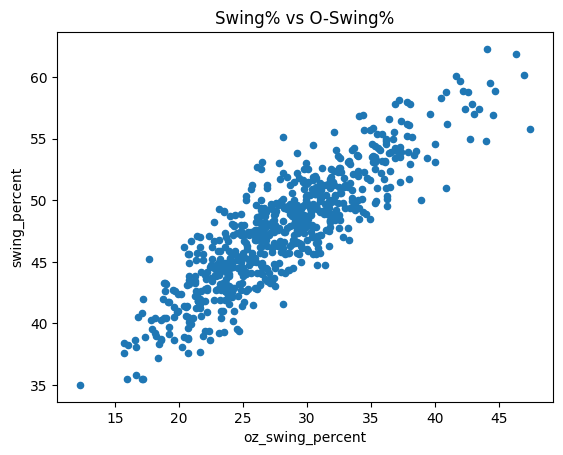

In [18]:
# Build and show scatterplots
scatter_plot(df, "z_swing_percent", "swing_percent", "Swing% vs Z-Swing%")
scatter_plot(df, "oz_swing_percent", "swing_percent", "Swing% vs O-Swing%")

Both Z-Swing% and O-Swing% share very strong, positive correlations with Swing%. The first two attributes are specific, holding unique relationships with other statistics in the dataset. However, Swing% is a rough average of the two, meandering in the middle and adding no further value to the dataset for analysis purposes. This very strong linear dependence implies it is a redundant feature that may not be needed for clustering.

### K% vs. Z-Contact%

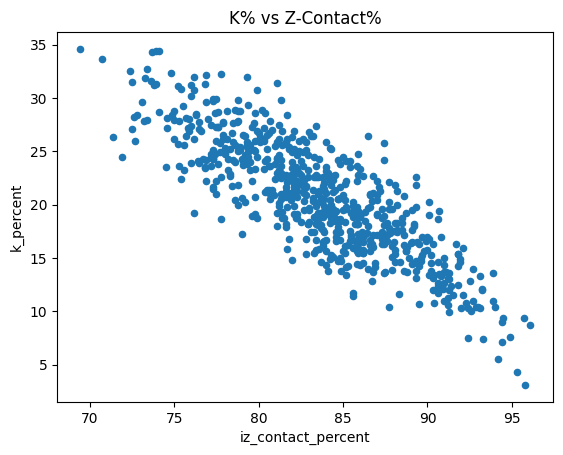

In [19]:
# Build and show scatterplot
scatter_plot(df, "iz_contact_percent", "k_percent", "K% vs Z-Contact%")

Batters who make more frequent bat-to-ball contact in the strike zone, whether fouling pitches off or putting them in play, generally strike out less, giving them better chances of reaching base. This correlation forms distinct ranges of players based on performance, allowing for various player groupings in future clustering, such as skilled contact hitters versus those who struggle to make contact, which affects strikeout rates differently.

### BB% vs. O-Swing%

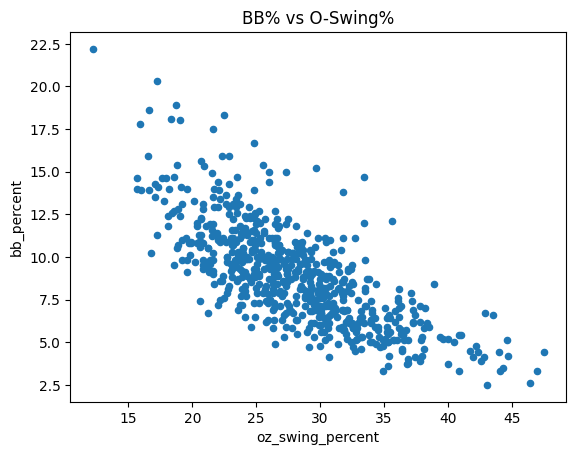

In [20]:
# Build and show scatterplot
scatter_plot(df, "oz_swing_percent", "bb_percent", "BB% vs O-Swing%")

The relation between O-Swing% and BB% shows that, typically, the more a batter swings outside the zone, the less they will walk. The scatterplot holds lots of variability in this field, but the correlation is still clear and strong, making for a useful association in clustering to find both aggressive and patient hitters, as well as how their approach affects their walk rates.

### xwOBA vs. wOBA

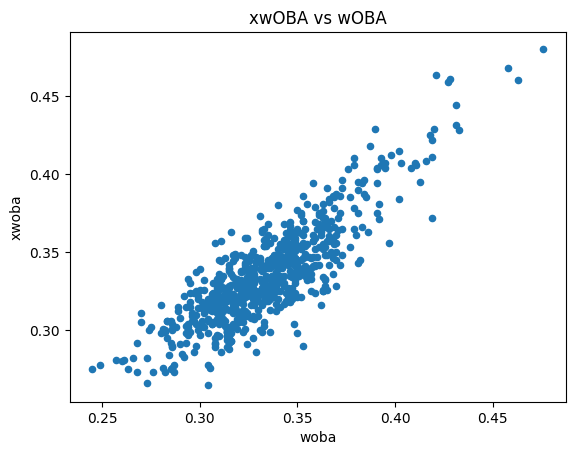

In [21]:
# Build and show scatterplot
scatter_plot(df, "woba", "xwoba", "xwOBA vs wOBA")

Many players fall in line with what is expected from their underlying statistics, but many also fall short or exceed their expected results. These differences will be crucial to measure, as they can help determine if any player profile clusters naturally lend themselves to more of these outliers than others, because many of them exist. Different batting approaches may hold stronger or weaker correlations with these differences, which will need to be analyzed after clustering.

### wOBA vs. K%

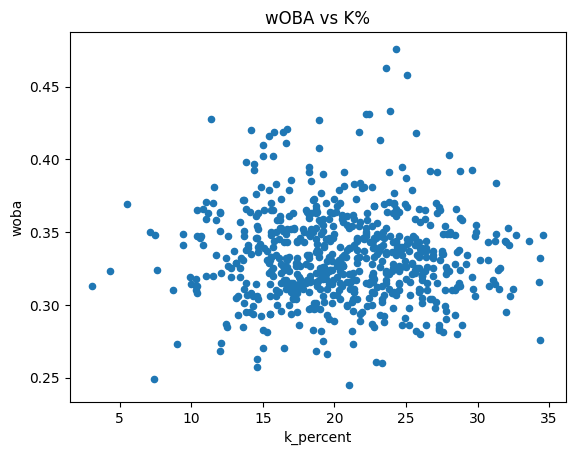

In [22]:
# Build and show scatterplot
scatter_plot(df, "k_percent", "woba", "wOBA vs K%")

The relationship between K% and wOBA is interesting to examine because it is intuitive to believe that a lower K% would lead to a higher weighted on-base average. However, as the scatterplot reveals, the lowest K% values do not exactly produce the higher wOBA's. Players can perform poorly with a low K%. Conversely, players can perform exceptionally with a high K%. The plot demonstrates that there are multiple paths to effectively getting on base at the major league level, and the need for additional attributes to showcase these other strategies and subsequent clusters.

## Impact

The performed bivariate and multivariate analyses demonstrate many key relationships within the dataset as well as the need for them, as some anticipated correlations are not as insightful as others. The need for a diverse set of features for the upcoming data mining phase is vital and will be settled upon next.

# Feature Engineering & Selection

The following creation and selection of attributes to be used in the data mining process and their subsequent evaluation are based upon the previous univariate, bivariate, and multivariate analysis.

## Feature Engineering

In [23]:
# Create and summarize new dataset feature, representing difference between wOBA and xwOBA
df["perf_diff"] = df["woba"] - df["xwoba"]
df["perf_diff"].describe()

count    669.000000
mean      -0.001484
std        0.017406
min       -0.048000
25%       -0.013000
50%       -0.002000
75%        0.010000
max        0.063000
Name: perf_diff, dtype: float64

This performance difference statistic was created to measure the difference between a player's expected weighted on-base average and their actual weighted on-base average to make it easier to view strictly whether a player matched their expected performance, without considering how well of a performance they actually recorded. The key is whether the player was under or over this expectation. If they were under, their performance difference would be negative, while it would be positive if they exceeded what was expected from them. The more positive or negative the value, the more strongly they overperformed or underperformed. After the clustering phase, this characteristic will be used as an evaluative attribute, comparing which clusters tend to overachieve, underachieve, or roughly match their expectations, providing answers to the related discovery question proposed.

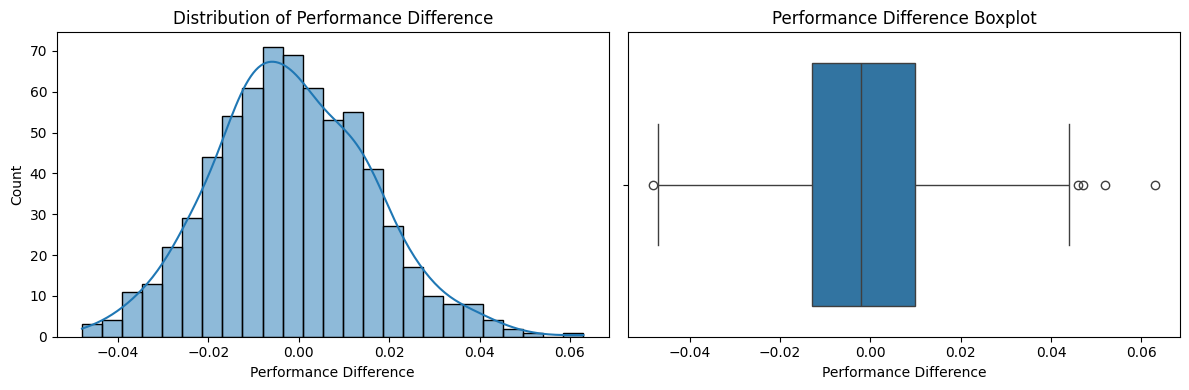

In [24]:
# Build and show histogram and boxplot
plot_feature(df, "perf_diff", "Performance Difference")

The distribution for the performance difference metric is unimodal but holds lots of variability, which gives cluster groupings the potential to be more concentrated in various ranges of the statistic. More outliers appear on the upper end of the spectrum, but more values fall on the lower half, accentuating this variety. Performance difference will be used to interpret clusters and locate outliers, so this variety serves to show the many different outcomes that exist.

## Feature Selection

There will be two sets of features chosen for the data mining stage. The first will be used for clustering, sorting player performance observations into distinct groups based on data describing their plate approach. The second set will be used for the post-clustering phase, including anomaly detection and comprehensive evaluations.

### Clustering Features

- Z-Swing%
- Z-Contact%
- O-Swing%
- O-Contact%
- BB%
- K%

These features measure the critical decisions batters take when at the plate, and what type of approach forms from those decisions. The metrics covering in-zone pitches reveal if a player is aggressive or passive in that area, and if the pitches they choose to swing at were intelligent decisions. The out-of-zone pitch statistics are similar. BB% and K%, on the other hand, are more widespread, giving a broader look into a player's characteristics and judging, in general, what kind of batter they are. Additionally, the Swing% metric was omitted because it was redundant, already covered by the Z-Swing% and O-Swing% measurements, as covered during the bivariate analysis. Swing% landed in the middle of these two attributes, acting as a median, not providing any additional value. These determinations leave a strong set of six features for cluster formation.

### Post-Clustering Features

- wOBA
- xwOBA
- Performance Difference

These metrics cover the outcomes of players, helping to interpret each formed cluster and its tendencies from a production standpoint. wOBA and xwOBA describe a player's pure on-base skill. Did they perform well or subpar? Did they exceed what was expected from them based on their underlying statistics or fall short of them? The performance difference measurement represents the disparity between these two features, focusing on the extent to which a player landed over or under their expectations without factoring in the actual quality of their performance itself. In this category, achieving a wOBA and xwOBA of 0.245 and 0.235, respectively, is equivalent to having those metrics valued at 0.392 and 0.382, respectively. In total, these characteristics can reveal patterns across the clusters, detect performance outliers, and provide insight into the advantages and disadvantages of each plate approach strategy as a result.

## Clustering Preparation

In [25]:
# Create and display data table for clustering holding only the chosen clustering features
clustering_features = ["z_swing_percent", "oz_swing_percent", "iz_contact_percent", "oz_contact_percent", "bb_percent", "k_percent"]
clustering_table = df[clustering_features]
clustering_table.head()

,z_swing_percent,oz_swing_percent,iz_contact_percent,oz_contact_percent,bb_percent,k_percent
0,69.1,30.2,82.0,57.1,7.6,22.4
1,73.8,31.0,77.3,52.6,8.7,21.6
2,66.3,27.4,86.8,59.9,8.6,17.1
3,67.9,26.2,85.8,63.9,9.3,15.6
4,63.7,19.1,81.1,50.5,14.1,23.0


The critical dimensions of the batter plate approach are represented by the table, created with minimal redundancy, and will be the input for clustering. Because the planned clustering algorithms are distance-based and sensitive to feature scaling, these selected attributes will be standardized next before any algorithms are implemented on them.

# Data Transformation

Data transformation will be executed through standardization, because even though the clustering values fall between 0 and 1 when converting their percentage values to decimals, their spreads are different within this range, biasing distance-based algorithms like K-Means. For example, K% ranges from 3-34%, while Z-Swing% stays between 52-83%. Utilizing standardization instead of simple min-max scaling retains variability and preserves the influence of outliers. All attributes will be centered at zero, allowing dispersions to become directly comparable and distances to be kept proportional for clustering.

In [26]:
# Set up standardization tools
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Standardize data
standardized_features = scaler.fit_transform(clustering_table)

# Create and summarize new table containing standardized features
standardized_table = pd.DataFrame(standardized_features, columns=clustering_features, index=clustering_table.index)
standardized_table.describe()

,z_swing_percent,oz_swing_percent,iz_contact_percent,oz_contact_percent,bb_percent,k_percent
count,6.690000e+02,6.690000e+02,6.690000e+02,6.690000e+02,6.690000e+02,6.690000e+02
mean,-2.527790e-15,3.186290e-16,-2.060468e-15,-1.593145e-16,1.354173e-16,9.027823e-17
std,1.000748e+00,1.000748e+00,1.000748e+00,1.000748e+00,1.000748e+00,1.000748e+00
min,-2.620102e+00,-2.750894e+00,-2.849082e+00,-2.491898e+00,-2.199073e+00,-3.244026e+00
25%,-6.903674e-01,-7.217870e-01,-6.940491e-01,-7.435926e-01,-7.218122e-01,-7.225237e-01
50%,-4.127467e-02,-9.744630e-02,1.086804e-02,1.654015e-02,-3.471436e-02,-1.798619e-02
75%,6.604472e-01,6.136084e-01,6.755042e-01,5.920692e-01,6.180286e-01,7.236322e-01
max,2.783156e+00,3.371113e+00,2.528429e+00,3.676036e+00,4.568841e+00,2.596219e+00


After the data transformation through standardization, all key attributes hold approximate means of 0 and standard deviations of 1. The distributions maintain relative proportions, which are now easily comparable due to their similar distance ranges, and are ready to be transferred into the clustering phase.

# Clustering

The clustering phase begins by selecting a clustering algorithm. Next, the number of clusters and their corresponding parameters will be decided on. Finally, the clusters will be formed, interpreted, and visualized to derive clear evaluations and takeaways from them.

## Algorithm Choice

The K-Means clustering algorithm was chosen to be applied to the dataset because the data is continuous and standardized, represented by normal distributions. The algorithm will provide clear, compact, and spherical cluster centers, representing meaningful batter archetypes that will be easily interpretable for analysis. The process of choosing k, the number of clusters, and its related parameters will be conducted next.

## K-Means Parameters

The key parameter in K-Means is k, or the number of clusters to extract from the dataset. To find this value, the elbow method will be employed and subsequently validated by finding the corresponding silhouette scores of the cluster options. The other K-Means input variables, including init, n_init, and random_state, will all maintain constant values for consistency.

### Elbow Method

The elbow method plots the number of clusters made from a dataset with the amount of in-cluster variation within them. Identifying the point at which this variation begins to significantly slow down yields the likely ideal cluster amount to select. It is not worth keeping more clusters than this found number due to diminishing returns, causing there to be minimal added value for each cluster included past this point, resulting in confusion and a lack of clarity.

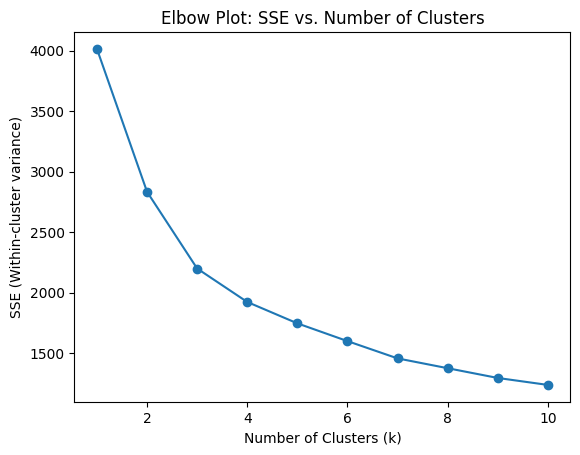

In [27]:
# Setup tools and list to store values
from sklearn.cluster import KMeans
sse_values = []

# Find within-cluster variance for cluster totals 1-10
for k in range(1, 11):
    km = KMeans(n_clusters=k)
    km.fit(standardized_table)
    sse_values.append(km.inertia_)

# Build and show resulting line graph
plt.figure()
plt.plot(range(1, 11), sse_values, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE (Within-cluster variance)")
plt.title("Elbow Plot: SSE vs. Number of Clusters")
plt.show()

The elbow of the graph appears to be located at k = 3, where the minimization of the sum of squares within clusters dramatically slows down compared to each other point. This takeaway will be compared against the silhouette scores computed for each potential cluster allocation to validate that this is the correct number of clusters to allot.

### Silhouette Scores

Because the elbow method is partly subjective, the silhouette scores of each cluster assignment will be taken to ensure the method's validity. These measurements will fall on a range of -1 to 1, with a positive value indicating a stronger cluster grouping and vice versa. This is based on how well each data point fits in its given cluster when compared to other clusters, so the more positive or negative the value, the stronger or weaker the formation is.

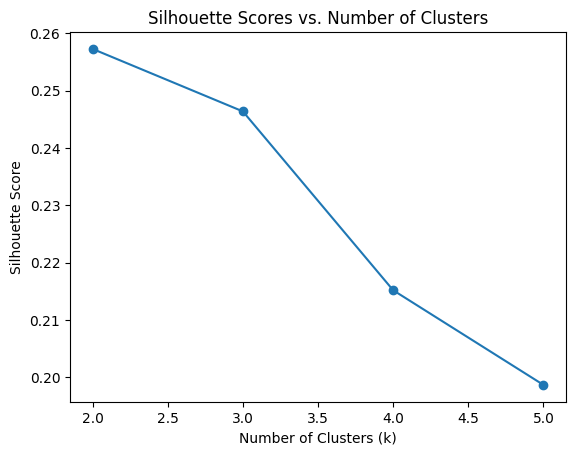

In [28]:
# Setup tools and list to store scores
from sklearn.metrics import silhouette_score
silhouette_scores = []

# Find scores for cluster amounts 2-5
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(standardized_table)
    score = silhouette_score(standardized_table, labels)
    silhouette_scores.append(score)

# Build and show resulting line graph
plt.figure()
plt.plot(range(2, 6), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores vs. Number of Clusters")
plt.show()

The silhouette scores for k values 2-5 were calculated, as this was the only range of competing cluster amounts based on the elbow method plot. From the silhouette score graph, k values 2 and 3 are the strongest, while values 4 and 5 are much weaker and can be discarded. A silhouette score of nearly 0.26 is produced from two formed clusters, while a third cluster causes this score to drop just below 0.25. A discrepancy of roughly 0.01 differentiates the two, making k = 2 the technically stronger option for cluster composition.

### Decision

After analyzing the results of the elbow method and silhouette score outputs, a value of k = 3 has been decided to use for K-Means Clustering. The elbow method visibly points to k = 3, and while the silhouette score for k = 2 is slightly stronger, the difference is not very substantive, so k = 3 will be kept to retain richer and more diverse groups for understanding. Furthermore, a k value of two clusters would simplify the dataset significantly, relinquishing its intricacies and losing its key attributes. The choice of three clusters, on the other hand, provides an ample template for analytical, evaluative, and interpretative purposes.

## Clustering Implementation

Now that the clustering algorithm choice has been decided on as well as the number of clusters to form, K-Means Clustering will be performed.

### Cluster Creation & Overview

In [29]:
# K-Means implementation
kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)
kmeans.fit(standardized_table)

# K-Means outputs
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Insert cluster labels back into original dataframe
df["cluster"] = labels
df["cluster"] = df["cluster"] + 1
df.head()

,"last_name, first_name",player_id,year,k_percent,bb_percent,woba,xwoba,z_swing_percent,oz_swing_percent,oz_contact_percent,iz_contact_percent,swing_percent,perf_diff,cluster
0,"Cabrera, Miguel",408234,2021,22.4,7.6,0.305,0.313,69.1,30.2,57.1,82.0,49.4,-0.008,2
1,"Cruz, Nelson",443558,2021,21.6,8.7,0.346,0.367,73.8,31.0,52.6,77.3,51.0,-0.021,2
2,"Peralta, David",444482,2021,17.1,8.6,0.314,0.294,66.3,27.4,59.9,86.8,46.5,0.020,3
3,"Blackmon, Charlie",453568,2021,15.6,9.3,0.333,0.358,67.9,26.2,63.9,85.8,47.3,-0.025,3
4,"McCutchen, Andrew",457705,2021,23.0,14.1,0.335,0.340,63.7,19.1,50.5,81.1,41.7,-0.005,1


K-Means has been implemented, and each player in the original dataset has been assigned a label from 1 to 3, denoting their cluster assignment.

In [30]:
# Calculate cluster totals
df["cluster"].value_counts()

cluster
2    251
3    222
1    196
Name: count, dtype: int64

The assortment of players in each cluster is slightly unbalanced, with cluster 2 holding the most at 251, cluster 1 holding the least at 196, and cluster 3 holding an amount in the middle at 222, close to the average between the other two clusters. This may mean that cluster 1 expresses more differentiated statistics because it contains a smaller sample size compared to the other clusters, while cluster 2 could be more centralized due to its relatively high population.

### Cluster Characterization

In [31]:
# Show means of key values in each cluster
df.groupby("cluster")[clustering_features].mean()

,z_swing_percent,oz_swing_percent,iz_contact_percent,oz_contact_percent,bb_percent,k_percent
cluster,,,,,,
1,64.857143,23.026531,80.964286,53.527551,11.766327,23.691837
2,72.123904,32.614343,81.331873,54.031474,7.126295,22.937849
3,65.314414,27.360360,88.328829,67.784685,8.377928,15.218018


Each cluster displays key differences in plate approach statistics according to their means, uncovering distinct batter archetypes.

Cluster 3 undoubtedly belongs to contact hitters, evidently holding the highest contact rates of the clusters. Their in-zone rate is 7% higher than the closest cluster, and their out-of-zone rate 13% higher, while also sporting the lowest strikeout rate among the clusters. This group's swing percentages and walk rate fall in the middle of the other clusters, suggesting their utility lies mainly in their contact ability despite their average approach to the plate in the other core areas.

Cluster 1 appears to belong to selective batters, as their swing percentages are the lowest among the three clusters, and their walk rate is the highest by 3%. This takeaway is also apparent by their contact percentages being the lowest as well. These batters are patient and make up for their weak bat-to-ball skills by choosing their swings more carefully than others. This results in high walk rates when pitchers are missing the zone often, but also high strikeout rates when pitchers are hitting their mark, as deeper counts leave players more susceptible to walking or striking out than otherwise.

Cluster 2 belongs to the most free-swinging of batters, suggested by their markedly high swing rates. Their contact rates are average, as can be expected with frequent swings, and their walk rate is the lowest of the clusters as a result. While they strikeout less than selective batters, by a difference of less than 1%, their rate is still significant: nearly 8% more than contact hitters. These numbers imply that this selection of hitters makes up for their deficiencies elsewhere, such as recording more extra-base hits than other players.

In [32]:
# Show standard deviations of key values in each cluster
df.groupby("cluster")[clustering_features].std()

,z_swing_percent,oz_swing_percent,iz_contact_percent,oz_contact_percent,bb_percent,k_percent
cluster,,,,,,
1,4.534517,3.226161,4.144895,6.588246,2.467614,4.293231
2,4.410413,4.638762,3.636298,6.477642,2.006616,3.854613
3,4.806864,4.538857,3.170463,6.305298,2.141786,3.348051


The standard deviations of these plate approach features across the clusters express how tightly packed or spread out they are. These numbers are mostly similar throughout, with a few exceptions. Cluster 1 differs significantly from the other two clusters regarding O-Swing%, as its value is much lower, even though it is the cluster that holds the smallest sample size. This suggests that the batters in this collection are extremely concentrated in that attribute, holding similar statistics. Another observation of note is Cluster 3's Z-Contact%, which is much lower than that of the other two clusters. This indicates that the contact hitters of this group are centralized together, which makes sense due to their skillset.

In [33]:
# Show means of performance metrics in each cluster
outcome_features = ["woba", "xwoba", "perf_diff"]
df.groupby("cluster")[outcome_features].mean()

,woba,xwoba,perf_diff
cluster,,,
1,0.343378,0.348546,-0.005168
2,0.330116,0.331546,-0.001430
3,0.329851,0.328144,0.001707


When it comes to the average performance outcomes of the three clusters, Cluster 1 stands out. The selective batters of this group get on base noticeably more than the very similar Clusters 2 and 3, with a 0.011, or 1.1%, edge on the nearest cluster. These statistics provide evidence that sound plate discipline gives a hitter noticeably better overall offensive value, generally speaking. This is helped by excellent walk rates and meticulous pitch selection. The expected statistics of Cluster 1 are even better as well, despite it owning the highest mean strikeout rate of the clusters. Clusters 2 and 3 perform very closely to what is expected from them, but Cluster 1 has the greatest underperforming difference at 0.5%, further cementing its edge over the other batter profiles. Their lower sample size must be regarded, but across the board, Cluster 1 delivers the more advantageous results by a fair margin, and so must be considered the ideal batter profile when taking into account comprehensive performance outcomes. Plate discipline has proven superior to both contact-based and swinging-based approaches.

In [34]:
# Show standard deviations of performance metrics in each cluster
df.groupby("cluster")[outcome_features].std()

,woba,xwoba,perf_diff
cluster,,,
1,0.034447,0.036509,0.016610
2,0.028419,0.027117,0.017297
3,0.030349,0.029963,0.017652


Cluster 1 holds the best mean performance outcomes, but also the most variance across wOBA and xwOBA. This indicates that the player performances are more spread out within the set, but still average higher results overall. In this case, plate discipline-based hitters may have a higher likelihood to perform more extremely, both positively and negatively, than the other plate approaches. This perceptible variance may also have been caused by Cluster 1's relatively low sample size, meaning the collection simply does not contain enough observations to centralize it to the extent that the other clusters are.

### Cluster Visualization

#### Grouped Bar Chart

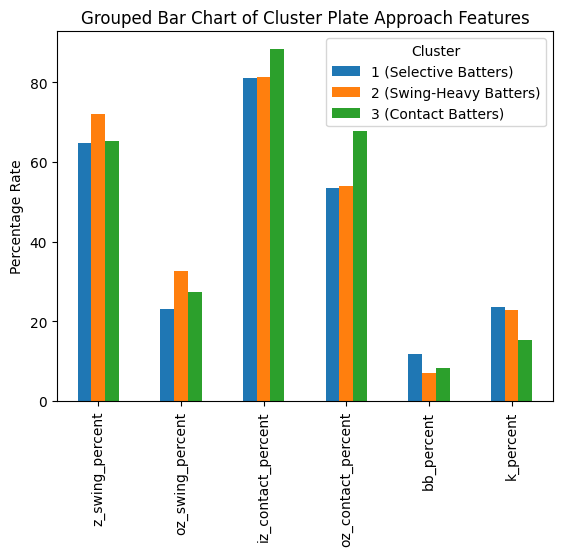

In [35]:
# Create custom legend to use for each chart
legend = ["1 (Selective Batters)", "2 (Swing-Heavy Batters)", "3 (Contact Batters)"]

# Build and show grouped bar chart of clusters showcasing plate approach metric differences
cluster_means = df.groupby("cluster")[clustering_features].mean()
cluster_means.T.plot(kind="bar", ylabel="Percentage Rate", title="Grouped Bar Chart of Cluster Plate Approach Features")
plt.legend(legend, title="Cluster")
plt.show()


The grouped bar chart of the clusters, focusing on plate approach features, backs up the previous cluster characterization evaluations. Each cluster has two categories in which it leads the other groupings, making each differentiation very clear for which cluster represents which batter profile.

#### Scatterplots

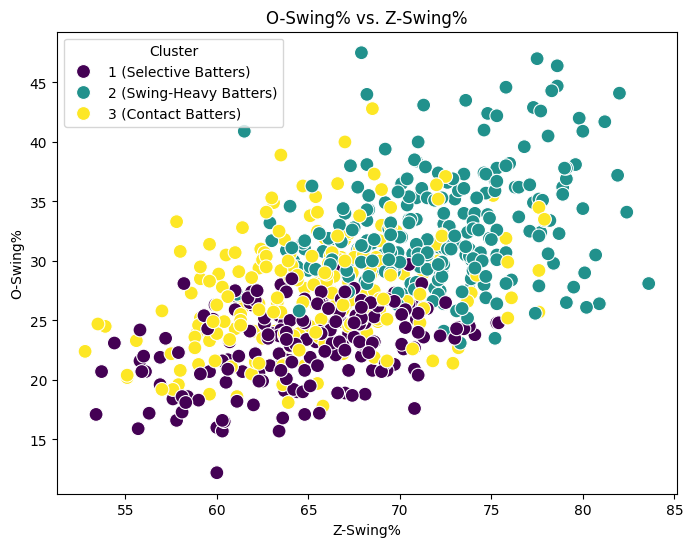

In [36]:
# Build scatterplot
plt.figure(figsize=(8, 6))
plot = sns.scatterplot(data=df, x='z_swing_percent', y='oz_swing_percent', hue='cluster', palette='viridis', s=100)
handles, labels = plot.get_legend_handles_labels()
plot.legend(handles=handles, labels=legend, title="Cluster")

# Label and show scatterplot
plt.xlabel("Z-Swing%")
plt.ylabel("O-Swing%")
plt.title("O-Swing% vs. Z-Swing%")
plt.show()

Comparing the positively correlated in-zone and out-of-zone swing percentages between the clusters reveals some separation. The batters of Cluster 2 swing very much and are distinctly represented in the upper right area of the graph. Additionally, batters who prioritize plate discipline, illustrated in Cluster 1, fall on the other end in the lower left region, as their swing rates are more diminished due to their detailed pitch selection. Cluster 3 holds batters who encompass both spectrums of the graph. Swing selection is not a big part of their strategy, so the data points fall all across the plot according to each player's preference.

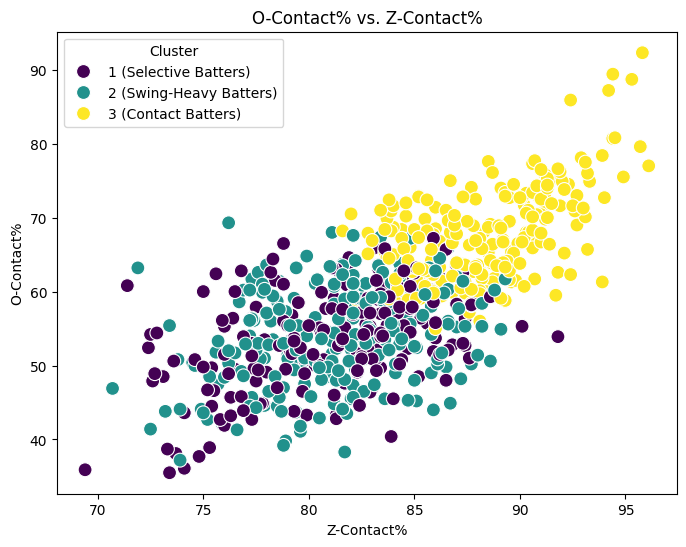

In [37]:
# Build scatterplot
plt.figure(figsize=(8, 6))
plot = sns.scatterplot(data=df, x='iz_contact_percent', y='oz_contact_percent', hue='cluster', palette='viridis', s=100)
handles, labels = plot.get_legend_handles_labels()
plot.legend(handles=handles, labels=legend, title="Cluster")

# Label and show scatterplot
plt.xlabel("Z-Contact%")
plt.ylabel("O-Contact%")
plt.title("O-Contact% vs. Z-Contact%")
plt.show()

Contrasting in-zone and out-of-zone contact percentages yields much different results in terms of differentiation. The only discerned cluster is Cluster 3, whose batters excel in bat-to-ball contact. All of these batters reside in the upper right portion of the plot. The other clusters, representing selective and swing-heavy batters, are very similar to each other. These batters don't put much focus into their contact rates; they concentrate on when to swing vs. when not to swing instead, so their contact rates will show no apparent discrepancies from one another.

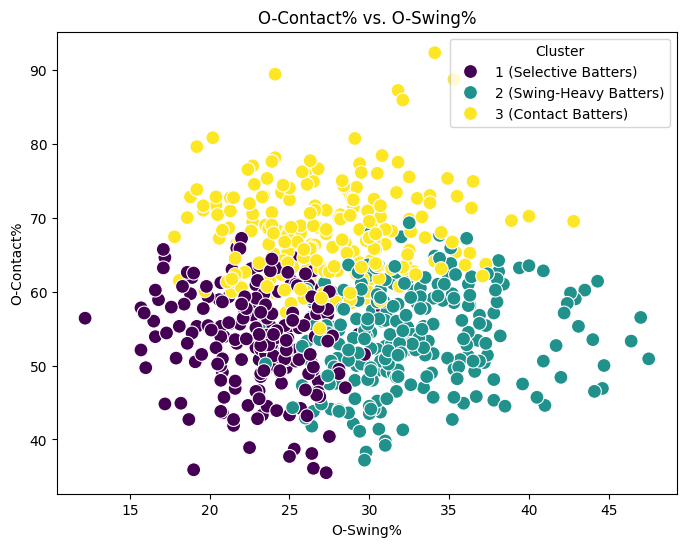

In [38]:
# Build scatterplot
plt.figure(figsize=(8, 6))
plot = sns.scatterplot(data=df, x='oz_swing_percent', y='oz_contact_percent', hue='cluster', palette='viridis', s=100)
handles, labels = plot.get_legend_handles_labels()
plot.legend(handles=handles, labels=legend, title="Cluster")

# Label and show scatterplot
plt.xlabel("O-Swing%")
plt.ylabel("O-Contact%")
plt.title("O-Contact% vs. O-Swing%")
plt.show()

The plot comparing out-of-zone swing percentage with contact rates on those swings defines each cluster most plainly. Contact hitters reside all along the upper portion of the graph, holding the largest range on the x-axis. This is because they prioritize contact, so they can get away with swinging or not swinging outside of the zone, as this does not affect their core goal: they have excellent chances of hitting the ball regardless, and therefore it doesn't play a role in their plate approach. Meanwhile, the bottom half of the graph is divided equally. On the left are the selective batters; they swing less and are not the best at making contact, performing average in that category, and make up for this with their plate discipline. The swing-heavy batters on the other side maintain around the same contact ability as selective batters because they swing so much rather than barely at all. Again, Clusters 1 and 2 remain on the same level in terms of O-Contact% but split regarding O-Swing%, while Cluster 3 rises above them both in O-Contact% but ranges on the O-Swing% scale. Cluster 3 is the best when considering out-of-zone contact percentage, Cluster 1 is the best regarding out-of-zone swing percentage, and Cluster 2 is the worst of both.

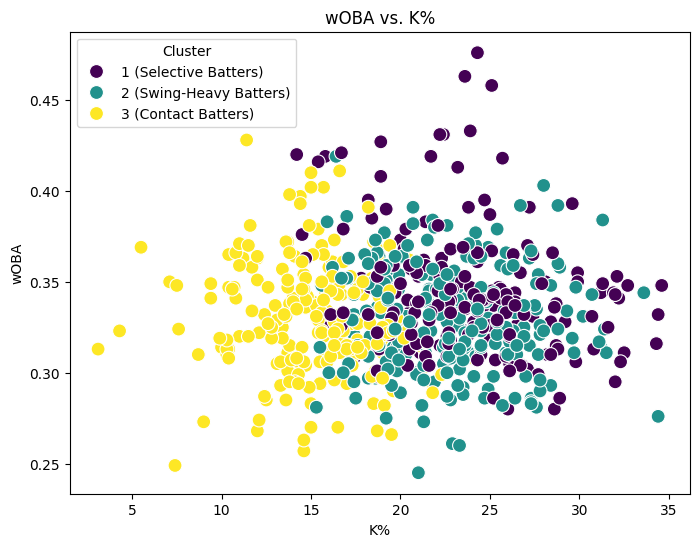

In [39]:
# Build scatterplot
plt.figure(figsize=(8, 6))
plot = sns.scatterplot(data=df, x='k_percent', y='woba', hue='cluster', palette='viridis', s=100)
handles, labels = plot.get_legend_handles_labels()
plot.legend(handles=handles, labels=legend, title="Cluster")

# Label and show scatterplot
plt.xlabel("K%")
plt.ylabel("wOBA")
plt.title("wOBA vs. K%")
plt.show()

Circling back to the comparison between K% and wOBA that was examined during Bivariate Analysis, there are a few subtelies now revealed by the comprised clusters. Firstly, it is clear that each plate approach strategy can achieve excellent offensive results, just in different ways. Cluster 3 is more differentiated with the lowest K%, while Clusters 1 and 2 average the same numbers on that front. However, as already identified, selective hitters are more consistent and effective offensively and have a noticeably higher wOBA minimum than the other two clusters. Because of this relatively high floor and ceiling holding distinct upper outliers, it is clear to see how this cluster produces a higher average wOBA, shedding light on the previously less detailed version of the graph showcased earlier.

#### Decision Tree

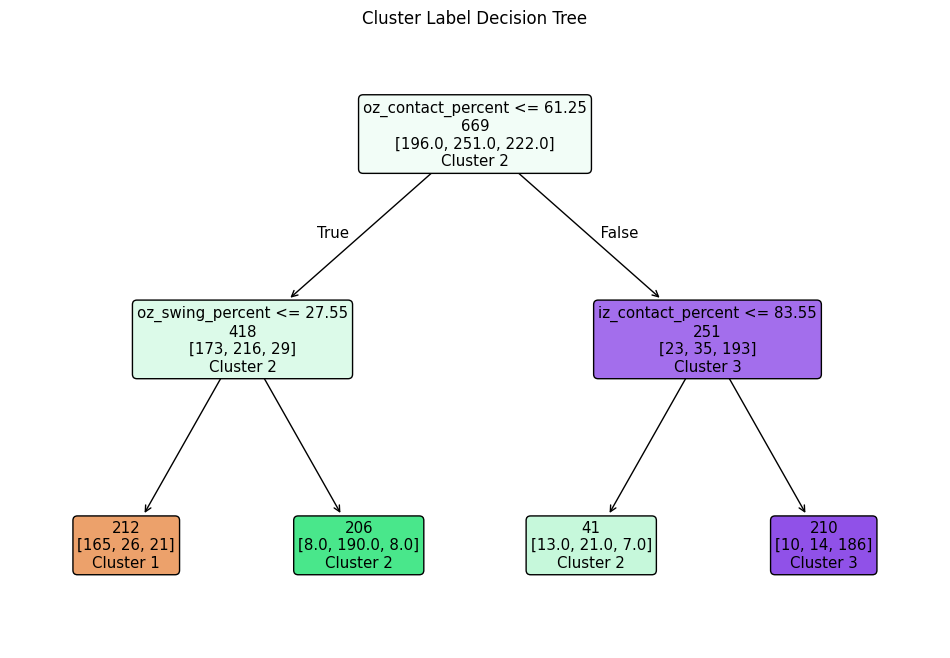

In [40]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Features and cluster labels
X = df[clustering_features]
y = df["cluster"]

# Create tree model
tree = DecisionTreeClassifier(max_depth=2, random_state=42)

# Fit model
tree.fit(X, y)

# Build and show decision tree
plt.figure(figsize=(12, 8))
plot_tree(
    tree,
    feature_names=clustering_features, 
    class_names=["Cluster 1", "Cluster 2", "Cluster 3"], 
    filled=True, 
    rounded=True,
    impurity=False,
    label='none'
)
plt.title("Cluster Label Decision Tree")
plt.show()

The decision tree on cluster labels gives the primary and secondary attributes of each cluster. It is clear that the most differentiating features between the clusters are swing and contact rates, measuring discipline and bat-to-ball ability, which are displayed below.

In [41]:
from sklearn.tree import export_text

rules = export_text(tree, feature_names=clustering_features)
print(rules)

|--- oz_contact_percent <= 61.25
|   |--- oz_swing_percent <= 27.55
|   |   |--- class: 1
|   |--- oz_swing_percent >  27.55
|   |   |--- class: 2
|--- oz_contact_percent >  61.25
|   |--- iz_contact_percent <= 83.55
|   |   |--- class: 2
|   |--- iz_contact_percent >  83.55
|   |   |--- class: 3



In [42]:
from sklearn.metrics import accuracy_score

y_pred = tree.predict(X)
print("Accuracy:", accuracy_score(y, y_pred))

Accuracy: 0.8400597907324364


The accuracy of the decision tree is not perfect, but still very high, confirming the validity of the tree.

## Clustering Findings & Interpretation

Exploratory data analysis and clustering implementation have uncovered concrete results that were previously unknown, allowing for interpretative conclusions and real-world meanings for the data.

### Results

The data analysis culminated in three distinct batting profiles for MLB players. These profiles are primarily defined by varying swing aggression and bat-to-ball contact ability and are most clearly separated along these axes, each staking out its own territory.

The clusters differentiate themselves by the strategies they use when at the plate. Cluster 1 ('Selective Batters') holds low swing and contact rates on balls outside and inside the strike zone, but high overall walk and strikeout rates. This suggests a methodology of patience and temperament, mixed in with a very specific mechanical technique, wherein batters work the count of balls and strikes, resulting in deeper counts. Swings are selected more carefully in these instances and make these at-bats more prone to ending in a walk or strikeout due to a pitch that is not swung at. The hitters of this group are picky, which can work both in their favor and against them depending on the situation.

Cluster 2 ('Swing-Heavy Batters') batters are defined by their swinging nature. They hold very high swing and strikeout rates, which hurts their contact and walk rates. This implies that these hitters are very aggressive and do not put much stock into walks or battling the opposing pitcher for an extended period of time. They put their eggs into the basket of trying to take advantage of most of the pitches thrown, hoping to inflict as much damage with their swings as possible, which is a double-edged sword; they could hit a home run or strikeout on three pitches, which would be far from the ideal plate appearance.

Cluster 3 ('Contact Batters') maintains a high contact ability across the board. These hitters focus on putting their bat on the ball no matter where it is located, avoiding strikeouts at all costs. Their swing rates vary, as choosing which pitches to swing at is not a central part of their strategy. The focus is that whenever they do swing, they hit the ball. This approach indicates an especially skilled talent that not all players have, so the select group that does carry it uses it greatly. They can get balls hit in play, improving the luck factor of baseball and opening up opportunities along the basepaths for other players, depending on the circumstances.

The MLB batters have different core approaches at the plate. Those who have a talent for putting their bat on the ball exceptionally more than most will tend to fall under Cluster 3, while the other two clusters are mainly defined through their swing rates. They are split so that low swing rate players will land in Cluster 1, while higher ones will fall under Cluster 2. This results in three very distinguishable clusters that can be defined purely through plate approach decisions, helping to understand how baseball works at its most fundamental level: hitting.

When it comes to performance results from each of these three clusters, one clearly stands out. Clusters 2 and 3 are nearly identical when comparing wOBA statistics, but Cluster 1 rises above them significantly, with a marked difference. This suggests that in broad terms, the plate approach of this cluster holds the greater average offensive value and reaches base more effectively than the others, making it the 'ideal' approach. However, there are limitations to this takeaway; this could be caused by where these types of batters are generally placed in batting orders, situational at-bats, or even just the fact that this cluster holds the smallest sample size of them all by a noteworthy margin. Further and deeper analysis is required to validate this determination. Nevertheless, it maintains the proper trend to hold true.

This can also be seen when comparing expected performance results through xwOBA. Again, Clusters 2 and 3 are very similar to their wOBA numbers difference-wise, each slightly underperforming and overperforming, respectively, but Cluster 1 differs significantly, underperforming much more noticeably than Cluster 2. This provides further evidence as to how well Cluster 1 batters perform against the other clusters. Their underlying measurements state that they should have performed even better than they actually did, not just by a small amount, but a very prominent one. This distinction further separates Cluster 1 from the other two clusters from a performance standpoint. The preliminary implication from all this is that these selective batters hold the greatest quality of contact and subsequent results from that contact, allowing them to reach base more effectively than others.

### Interpretative Findings

Broadly, these conclusions suggest a few things about MLB batters. Most importantly, a player can fall under any category of cluster and still perform exceptionally or horrendously performance-wise; the categorization does not define their potential. Additionally, there were some unexpected findings.

Plate discipline, as represented in Cluster 1 batters, does not necessarily mean fewer strikeouts. Cluster 1 holds the highest mean strikeout rate of the clusters, and this can be derived through the shared patience of the batters, as they can be too selective for their own good. They can strikeout looking, wanting a better pitch to swing at, or by swinging in a panic when they wouldn't normally swing, but had to due to the deep count they worked themselves into.

Another surprising finding is how strikeout rates do not impact wOBA as much as anticipated. Many players perform excellently with high strikeout rates and poorly with low strikeout rates. The takeaway from this is that decreasing strikeouts does not mean a player is getting on base more effectively, as they can still be making weak contact and easy outs as a result. Inversely, high-strikeout players can make up for this deficiency by making loud contact and recording more extra-base hits, boosting their wOBA significantly. Strikeout rate is just one factor of many, and so a player cannot be scrutinized based on it alone.

Lastly, it is interesting how Cluster 1 is the clear performance output leader of the clusters. It may have been expected to see all three groupings very similar to each other based on these metrics, so this is surprising. It can be assumed that, despite the high strikeout rate, as just covered before, the combination of a high walk rate and selective swings gives this group of batters the edge over all others. This plate approach results in an average higher performance result, notwithstanding sample size limitations and ambiguity of how these batters are used on a day-to-day basis.

Expected findings include simple causes and effects, such as high contact rates in Cluster 3 resulting in significantly fewer strikeouts, and high swing rates resulting in more strikeouts, as seen in Cluster 2.

### Real World Applications

Within the MLB domain, these discoveries can be utilized in a variety of ways.

In the construction of lineups, for instance, a manager may want the leading batter to be a contact-based hitter to minimize the chances of the opposing pitcher starting the game off with a strikeout, and may like an aggressive hitter in the third or fourth spot, since that is usually where extra-base hits count the most. Additionally, pinch-hit situations also play a role. If it's late in a close game and the current pitcher on the mound is struggling, then a selective hitter may be the key, boosting the chances to work a walk and henceforth improving the likelihood of scoring.

Knowing these strengths and weaknesses of players is essential for deciding on how to best employ them, which is what the formed clusters accomplish. Furthermore, they can help in overall roster selection and player acquisitions, ensuring that there is an appropriate number of each batting archetype on the team. This guides offseason activity as well, as teams can compare the best available players on the market to sign or trade for based on this cluster data. Inversely, from a defensive viewpoint, this knowledge can be used to decide on the best pitching matchups and defensive positioning based on developed scouting reports based on this information, which goes beyond the scope of this project.

# Anomaly Detection

Anomaly detection will be used to locate players who are exceptions to their assigned cluster, plate approach-wise and performance-wise, and to view which clusters lend themselves to such outliers. There may be groupings with several of these anomalies, while others may have very few. Execution of these methods will involve calculating the Euclidean distance from each data point to its cluster centroid and the Z-Scores of the performance difference metric within each cluster, assessing these values to identify outliers, and evaluating them thereafter.

## Structural Anomalies

Structural anomalies are represented by players who fall far from their assigned cluster centroid, in some cases as true outliers and in others as edge cases representing hitters who take on a more hybrid approach at the plate. These instances will be identified by taking the Euclidean distances between the cluster centroids and the data points, as well as by calculating a hybrid score that represents the difference in centroid distances between the assigned cluster centroid and the next closest cluster centroid. High centroid distances indicate outlier anomalies, while low hybrid scores indicate hybrid anomalies as batting profiles that blend multiple plate approaches.

### Implementation

In [43]:
# Take cluster centroids and labels from kmeans data
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

# Find Euclidean distances of data observations to each cluster centroid
distances = kmeans.transform(standardized_table)

# Find Euclidean distances of data observations to assigned cluster centroid
centroid_distances = distances[np.arange(len(labels)), labels]

# Add centroid distance to dataframe
df["centroid_distance"] = centroid_distances
df.head()

,"last_name, first_name",player_id,year,k_percent,bb_percent,woba,xwoba,z_swing_percent,oz_swing_percent,oz_contact_percent,iz_contact_percent,swing_percent,perf_diff,cluster,centroid_distance
0,"Cabrera, Miguel",408234,2021,22.4,7.6,0.305,0.313,69.1,30.2,57.1,82.0,49.4,-0.008,2,0.788862
1,"Cruz, Nelson",443558,2021,21.6,8.7,0.346,0.367,73.8,31.0,52.6,77.3,51.0,-0.021,2,1.096465
2,"Peralta, David",444482,2021,17.1,8.6,0.314,0.294,66.3,27.4,59.9,86.8,46.5,0.020,3,0.992675
3,"Blackmon, Charlie",453568,2021,15.6,9.3,0.333,0.358,67.9,26.2,63.9,85.8,47.3,-0.025,3,0.888233
4,"McCutchen, Andrew",457705,2021,23.0,14.1,0.335,0.340,63.7,19.1,50.5,81.1,41.7,-0.005,1,1.128267


After finding the Euclidean distances between each cluster centroid and keeping only the distance between the data point and its assigned cluster centroid, these values were added to the dataframe. They will now be used to identify outlier points that are extremely far from their respective cluster centroids. These will be defined as the points that exceed the 95th percentile of the data, i.e., the upper 5% in terms of centroid distance, which will be the highest values extracted. This threshold was chosen because it flags only statistically unusual points without being overly strict or yielding too many false positives, and it is a widely used threshold value. It will also allow the identification of players who are uniquely grounded in their respective plate approach. The plate approach statistics must be so extreme that they are legitimate and not a random occurrence, helping to filter out noise from the real signals.

In [44]:
# Find 95th percentile of centroid distance for each cluster
thresholds = df.groupby("cluster")["centroid_distance"].quantile(0.95)

# Compare values in each cluster to that cluster's threshold to find anomalies and add to dataframe
df["outlier_anomaly"] = df["centroid_distance"] > df["cluster"].map(thresholds)
df.head()

,"last_name, first_name",player_id,year,k_percent,bb_percent,woba,xwoba,z_swing_percent,oz_swing_percent,oz_contact_percent,iz_contact_percent,swing_percent,perf_diff,cluster,centroid_distance,outlier_anomaly
0,"Cabrera, Miguel",408234,2021,22.4,7.6,0.305,0.313,69.1,30.2,57.1,82.0,49.4,-0.008,2,0.788862,False
1,"Cruz, Nelson",443558,2021,21.6,8.7,0.346,0.367,73.8,31.0,52.6,77.3,51.0,-0.021,2,1.096465,False
2,"Peralta, David",444482,2021,17.1,8.6,0.314,0.294,66.3,27.4,59.9,86.8,46.5,0.020,3,0.992675,False
3,"Blackmon, Charlie",453568,2021,15.6,9.3,0.333,0.358,67.9,26.2,63.9,85.8,47.3,-0.025,3,0.888233,False
4,"McCutchen, Andrew",457705,2021,23.0,14.1,0.335,0.340,63.7,19.1,50.5,81.1,41.7,-0.005,1,1.128267,False


Each data point has now been flagged for outlier anomalies, represented as boolean values added to the dataframe. A similar anomaly-detection process will now be conducted to locate hybrid anomalies in the dataset, this time using the distances between data points and the centroids of multiple clusters. By calculating the differences between these distances and representing them as a hybrid score, it can be seen which data points lie mostly in the middle of two clusters, not clearly committed to either, indicating a hybrid plate approach.

In [45]:
# Sort centroid distances for each point in increasing order
sorted_distances = np.sort(distances, axis=1)

# Extract first two points of sorted array for each data point as the nearest and second nearest centroid distances
nearest = sorted_distances[:, 0]
second_nearest = sorted_distances[:, 1]

# Calculate hybrid score using nearest and second nearest values
hybrid_score = second_nearest - nearest

# Add hybrid score to dataframe
df["hybrid_score"] = hybrid_score
df.head()

,"last_name, first_name",player_id,year,k_percent,bb_percent,woba,xwoba,z_swing_percent,oz_swing_percent,oz_contact_percent,iz_contact_percent,swing_percent,perf_diff,cluster,centroid_distance,outlier_anomaly,hybrid_score
0,"Cabrera, Miguel",408234,2021,22.4,7.6,0.305,0.313,69.1,30.2,57.1,82.0,49.4,-0.008,2,0.788862,False,1.309198
1,"Cruz, Nelson",443558,2021,21.6,8.7,0.346,0.367,73.8,31.0,52.6,77.3,51.0,-0.021,2,1.096465,False,1.391189
2,"Peralta, David",444482,2021,17.1,8.6,0.314,0.294,66.3,27.4,59.9,86.8,46.5,0.020,3,0.992675,False,1.222829
3,"Blackmon, Charlie",453568,2021,15.6,9.3,0.333,0.358,67.9,26.2,63.9,85.8,47.3,-0.025,3,0.888233,False,1.514637
4,"McCutchen, Andrew",457705,2021,23.0,14.1,0.335,0.340,63.7,19.1,50.5,81.1,41.7,-0.005,1,1.128267,False,2.554996


The previously computed cluster centroid distances have now been used to select the two closest cluster centroids to create a hybrid score indicating whether the given anomaly represents an edge case for extremely low values. High values indicate a data point that is independent and clearly belongs to its assigned cluster, while low values indicate a point caught between two clusters. The calculated hybrid score will now have a similar threshold applied to it to identify concrete hybrid anomalies with low hybrid scores. Therefore, its threshold will be set to the lower 5% of the dataset to find low values rather than high ones, highlighting hybrid plate approaches.

In [46]:
# Find 5th percentile of hybrid score for each cluster
hybrid_thresholds = df.groupby("cluster")["hybrid_score"].quantile(0.05)

# Compare values in each cluster to that cluster's threshold to find anomalies and add to dataframe
df["hybrid_anomaly"] = df["hybrid_score"] < df["cluster"].map(hybrid_thresholds)
df.head()

,"last_name, first_name",player_id,year,k_percent,bb_percent,woba,xwoba,z_swing_percent,oz_swing_percent,oz_contact_percent,iz_contact_percent,swing_percent,perf_diff,cluster,centroid_distance,outlier_anomaly,hybrid_score,hybrid_anomaly
0,"Cabrera, Miguel",408234,2021,22.4,7.6,0.305,0.313,69.1,30.2,57.1,82.0,49.4,-0.008,2,0.788862,False,1.309198,False
1,"Cruz, Nelson",443558,2021,21.6,8.7,0.346,0.367,73.8,31.0,52.6,77.3,51.0,-0.021,2,1.096465,False,1.391189,False
2,"Peralta, David",444482,2021,17.1,8.6,0.314,0.294,66.3,27.4,59.9,86.8,46.5,0.020,3,0.992675,False,1.222829,False
3,"Blackmon, Charlie",453568,2021,15.6,9.3,0.333,0.358,67.9,26.2,63.9,85.8,47.3,-0.025,3,0.888233,False,1.514637,False
4,"McCutchen, Andrew",457705,2021,23.0,14.1,0.335,0.340,63.7,19.1,50.5,81.1,41.7,-0.005,1,1.128267,False,2.554996,False


All data points have now been flagged for outlier and hybrid anomalies. All points that are positive for one or both measurements can now be examined and visually compared with non-anomalies to determine differences and reveal underlying characteristics and patterns.

### Analysis

In [47]:
# Count True and False outlier anomaly values
df["outlier_anomaly"].value_counts()

outlier_anomaly
False    634
True      35
Name: count, dtype: int64

In [48]:
# Count True and False hybrid anomaly values
df["hybrid_anomaly"].value_counts()

hybrid_anomaly
False    634
True      35
Name: count, dtype: int64

Both anomaly types have the same count of 35 True instances, roughly 5% of the dataset, confirming the threshold values set earlier.

In [49]:
# Count True outlier anomaly values across each cluster
df.groupby("cluster")["outlier_anomaly"].sum()

cluster
1    10
2    13
3    12
Name: outlier_anomaly, dtype: int64

In [50]:
# Count True hybrid anomaly values across each cluster
df.groupby("cluster")["hybrid_anomaly"].sum()

cluster
1    10
2    13
3    12
Name: hybrid_anomaly, dtype: int64

Both anomalies exhibit the same distribution across the cluster groups because they hold nearly perfectly balanced values. Cluster 1 holds 10 occurrences of each anomaly, while Clusters 2 and 3 hold 13 and 12, respectively. This suggests that there is no particular cluster most vulnerable to these anomalies, and that they are mostly random, with no single cluster having a higher chance of containing a structural anomaly than any other. It is reasonable to assume that each plate approach represented by the clusters has a roughly equal number of players who deeply fit into each one.

In [51]:
# Display averages for the features used for clustering across each cluster
df.groupby("cluster")[clustering_features].mean()

,z_swing_percent,oz_swing_percent,iz_contact_percent,oz_contact_percent,bb_percent,k_percent
cluster,,,,,,
1,64.857143,23.026531,80.964286,53.527551,11.766327,23.691837
2,72.123904,32.614343,81.331873,54.031474,7.126295,22.937849
3,65.314414,27.360360,88.328829,67.784685,8.377928,15.218018


Displayed are the cluster averages for the features used in the clustering phase, to analyze and evaluate anomalies that stray from these averages.

In [52]:
# Display outlier anomaly data observations with the highest centroid distance values
df[df["outlier_anomaly"]].sort_values(by="centroid_distance", ascending=False).head(10)[["last_name, first_name", "year", "cluster", "centroid_distance", "hybrid_score"] + clustering_features]

,"last_name, first_name",year,cluster,centroid_distance,hybrid_score,z_swing_percent,oz_swing_percent,iz_contact_percent,oz_contact_percent,bb_percent,k_percent
118,"Soto, Juan",2021,1,4.588773,1.091629,60.0,12.2,85.3,56.4,22.2,14.2
72,"Gallo, Joey",2021,1,4.273104,1.701240,64.4,19.0,69.4,35.9,18.0,34.6
243,"Soto, Juan",2022,1,4.163131,0.601598,56.3,17.2,86.2,64.6,20.3,14.5
569,"Arraez, Luis",2025,3,4.161999,2.366490,62.7,34.1,95.8,92.3,5.0,3.1
439,"Arraez, Luis",2024,3,3.997808,2.188823,63.0,35.3,95.3,88.7,3.6,4.3
62,"Báez, Javier",2021,2,3.783382,1.792904,75.8,44.6,70.7,46.9,5.1,33.6
497,"Rafaela, Ceddanne",2024,2,3.336125,2.453277,78.6,46.4,75.7,53.3,2.6,26.4
496,"Tovar, Ezequiel",2024,2,3.312311,2.403756,82.0,44.1,78.1,46.5,3.3,28.8
324,"Arraez, Luis",2023,3,3.295616,2.252776,68.6,31.8,94.2,87.2,5.7,5.5
357,"Soto, Juan",2023,1,3.285870,1.049606,57.8,16.6,85.8,60.2,18.6,18.2


The players with the highest distances from their respective cluster centroids appear to exemplify extreme cases of their plate approaches. They do not lean towards any other cluster, which is why their hybrid scores are higher, but instead lean far in the opposite direction in an intense showing of their plate approach that falls much farther than most other players. Cluster 1 anomalies have very low swing rates, Cluster 2 anomalies have very high swing rates, and Cluster 3 anomalies have very high contact rates. Examples of each include 2021 Juan Soto, who paired a league-leading 22.2% walk rate with a career-low 12.2% O-Swing%; 2024 Ezequiel Tovar, who struck out 28.8% of the time and rarely walked (3.3%) due to aggressive 82% Z-Swing and 44.1% O-Swing rates; and 2025 Luis Arraez, who made contact on nearly every swing, posting a 95.8% Z-Contact% and 92.3% O-Contact%, and struck out just 3.1% of the time. These are very drastic circumstances that serve as outliers compared to the general MLB batting pool, because these players are significantly rooted in their plate approach strategy, fitting almost too well into one of the three formed clusters.

In [53]:
# Display outlier anomaly average statistics for the features used for clustering across each cluster
df[df["outlier_anomaly"]].groupby("cluster")[clustering_features].mean()

,z_swing_percent,oz_swing_percent,iz_contact_percent,oz_contact_percent,bb_percent,k_percent
cluster,,,,,,
1,61.060000,19.480000,80.980000,50.350000,15.540000,23.720000
2,75.746154,39.130769,79.307692,49.638462,6.138462,25.323077
3,63.500000,28.741667,91.375000,79.841667,7.700000,10.358333


The found extremeness can be seen in the anomaly averages for the features used for clustering. Cluster 1 batters show extreme selectiveness, signified by the 19.5% O-Swing% and 15.5% walk rate. Cluster 2 batters show varying strikeout and walk rates, denoted by the 6.1% BB% and 25.3% K% rates. Cluster 3 batters show elevated contact rates, illustrated by the 91.4% Z-Contact% and 79.8% O-Contact% rates. This provides further evidence for the idea that batters identified as outliers retain entrenched plate approaches that align perfectly with their assigned cluster.

In [54]:
# Display hybrid anomaly data observations with the lowest hybrid score values
df[df["hybrid_anomaly"]].sort_values(by="hybrid_score").head(10)[["last_name, first_name", "year", "cluster", "centroid_distance", "hybrid_score"] + clustering_features]

,"last_name, first_name",year,cluster,centroid_distance,hybrid_score,z_swing_percent,oz_swing_percent,iz_contact_percent,oz_contact_percent,bb_percent,k_percent
90,"Adames, Willy",2021,2,2.163646,0.012487,72.2,27.5,75.7,47.5,10.3,28.1
239,"Bohm, Alec",2022,3,2.062859,0.015295,72.0,31.4,83.9,68.2,4.9,17.4
65,"Candelario, Jeimer",2021,2,1.695418,0.018616,68.6,29.2,84.8,59.3,10.4,21.6
566,"Albies, Ozzie",2025,3,2.540698,0.019442,77.9,33.5,85.2,67.3,8.2,14.1
586,"Raleigh, Cal",2025,2,2.593687,0.022662,75.0,31.8,78.4,48.5,13.8,26.7
291,"Lindor, Francisco",2023,2,1.702070,0.030689,70.3,27.2,83.9,61.2,9.6,19.9
304,"Meneses, Joey",2023,2,1.809737,0.039979,64.7,31.5,85.8,58.0,5.8,19.8
160,"Urshela, Gio",2022,2,1.996866,0.040071,71.2,36.1,84.8,67.2,7.4,17.4
626,"Wagaman, Eric",2025,2,2.064692,0.045322,64.5,25.8,85.0,52.6,6.2,19.5
468,"Cruz, Oneil",2024,2,2.479891,0.048688,63.0,31.7,76.0,48.4,8.5,30.2


The players with the lowest hybrid scores are very closely aligned with another cluster group to which they are not assigned, indicating that parts of their underlying statistics point in one strategic direction while other areas point in another. This results in a placement between clusters where the player is caught in the middle, forced to be assigned to one group, resulting in an inaccurate reflection of the batter's true plate approach. The lowest hybrid scores come from Cluster 2 batters, indicating that more players in this grouping are much closer to other clusters than other players from other clusters are. This may be because these Cluster 2 swing-heavy batters are able to share other cluster statistics more easily than other types of players. They may be able to make high contact despite high swing rates, or hold low strikeout rates and high walk rates, contradicting the Cluster 2 archetype. For example, 2021 Willy Adames had a 72.2% Z-Swing% and 28.1% K%, typical for a Cluster 2 batter, but also held a 10.3% BB% and O-Swing% of 27.5%, suggesting a more controlled plate approach more similar to the selective batters that make up Cluster 1. Vice versa, 2025 Ozzie Albies had the swing rates of a standard Cluster 2 hitter, at 77.9% for Z-Swing% and 33.5% for O-Swing%, but Cluster 3-like measurements for other critical features, such as a 67.3% O-Contact% and 14.1% K rate, prompting a Cluster 3 assignment as a selective batter rather than a Cluster 2 swing-heavy one, despite the high swing rates. These examples demonstrate the exact blending of plate approaches hypothesized, because these players share attributes across plate approaches and clusters and do not fit neatly into a single classification.

In [55]:
# Display hybrid anomaly average statistics for the features used for clustering across each cluster
df[df["hybrid_anomaly"]].groupby("cluster")[clustering_features].mean()

,z_swing_percent,oz_swing_percent,iz_contact_percent,oz_contact_percent,bb_percent,k_percent
cluster,,,,,,
1,65.930000,23.620000,83.920000,59.340000,11.020000,20.750000
2,69.500000,28.938462,82.223077,54.600000,8.930769,23.023077
3,70.166667,31.391667,85.525000,62.766667,7.608333,16.941667


In contrast to the clustering feature averages of the outer anomalies, the averages of the hybrid anomalies pack much more closely together, meaning they mix more and share different values. For example, the Z-Swing% range here is between 65-70%, while for the outlier anomalies, it stayed at 61-75%. Furthermore, the Z-Contact% range is 83-85% here, while the outlier anomalies range from 79-91%. Clearly, the values have become much more centered, as reflected in these narrower ranges. This means a bordering of points between clusters, with points staying closely together.

### Visualization

Both structural anomaly types can be visualized in a scatterplot, depicting where they fall relative to the rest of the data points.

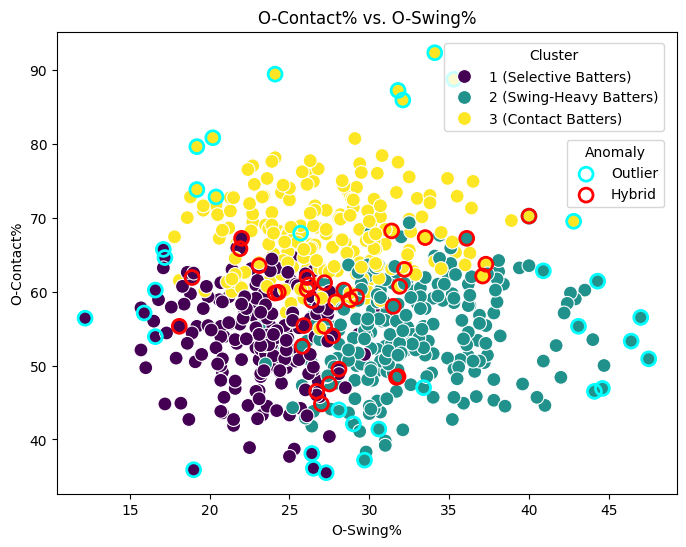

In [56]:
# Build scatterplot
plt.figure(figsize=(8, 6))
plot = sns.scatterplot(data=df, x='oz_swing_percent', y='oz_contact_percent', hue='cluster', palette='viridis', s=100)

# Build overlay scatterplot for highlighting outlier anomalies
sns.scatterplot(
    data=df[df["outlier_anomaly"] == True], 
    x='oz_swing_percent', y='oz_contact_percent',
    facecolor='none', edgecolor='aqua', linewidth=2, s=100, label="Outlier"
)

# Build overlay scatterplot for highlighting hybrid anomalies
sns.scatterplot(
    data=df[df["hybrid_anomaly"] == True], 
    x='oz_swing_percent', y='oz_contact_percent',
    facecolor='none', edgecolor='red', linewidth=2, s=100, label="Hybrid"
)

# Find values needed for legends
num_clusters = df['cluster'].nunique()
handles, labels = plot.get_legend_handles_labels()

# Add cluster legend
cluster_legend = plot.legend(handles=handles[:num_clusters], labels=legend, 
                             title="Cluster", loc='upper right', bbox_to_anchor=(0.99, 0.99))
plot.add_artist(cluster_legend)

# Add anomaly legend
anomaly_legend = plot.legend(handles=handles[num_clusters:], labels=labels[num_clusters:], 
                             title="Anomaly", loc='upper right', bbox_to_anchor=(0.99, 0.78))

# Label and show scatterplot
plt.xlabel("O-Swing%")
plt.ylabel("O-Contact%")
plt.title("O-Contact% vs. O-Swing%")
plt.show()

The scatterplot above highlights the different structural anomalies previously examined. The outlier anomalies are mainly scattered around the edges of the graph, indicating their outlier status. Hybrid anomalies are much more saturated near and around the center of the graph, and this validates the blending of plate approaches, as some Cluster 3 assignments are planted in Cluster 2 territory and vice versa. The majority of them fill the intersections between the clusters, forming unclear regions that can contain points from any cluster. The scarce data points for anomalies that do not match the locations according to these findings indicate that these must not be the features upon which they differentiate themselves from the rest of their cluster assignment. Outlier or hybrid points may be more distinguished in the Z-Swing% metric, for instance.

### Results

The outlier and hybrid anomalies found in the prior analysis validate the existence of two types of extraneous players purely from a plate approach standpoint, relative to the cluster distributions: outlier and hybrid structural anomalies. They were found using Euclidean distance to cluster centroids, which reflect multivariate deviation rather than focusing on a single measurement. 

Some players are so entrenched in a plate approach defined by one of the three formed clusters that they become outliers because of the extreme nature of their statistics. For example, this may include a swing-heavy batter from Cluster 2 that possesses overwhelming in- and out-of-zone swing rates that are well beyond the average for Cluster 2 hitters. Such a player may be particularly distinguished in this way by one or more features, as long as they align with the trend of the cluster grouping.

The other category is hybrid players who sit on the boundary of different plate approaches defined by the clusters. They do not fit squarely within the limitations of any cluster and, as a result, form edge cases of plate approaches. For example, this may include a selective batter from Cluster 1 who also has excellent contact rates on pitches in- and out-of-the zone, a trait mainly exemplified by Cluster 3 hitters. In such a case, the player must be assigned to one of the formed clusters, but in reality hovers in the middle of them. 

Thresholds were chosen at the 95th and 5th percentiles for the outlier and hybrid anomalies, respectively, because they separate the bulk of the player data from the extreme data represented by the upper and lower 5% of the data. These percentile choices were the best option due to the sensitivity of the player data and to avoid identifying irrelevant data points that did not meet the criteria.

These anomalies are almost symmetrically distributed between the three clusters: 10 in Cluster 1, 13 in Cluster 2, and 12 in Cluster 3 for each type. This shows a balanced cluster structure with similar overall variance. Therefore, it cannot be said that any single cluster is more likely to hold structural anomalies than any other. This makes sense, as outliers represented by structural anomalies are just as likely to appear in each cluster, while hybrid anomalies can border any two clusters, making their positioning just as random as well, with near equal distances between any two clusters.

The limitations of this anomaly detection may include misclassifying points as anomalies when they are, in reality, boundary points. Another issue is that these anomalies are based on model-defined clusters, and thus may not be fully accurate when looking at these data points without clustering applied.

Treating the found anomalies as an extension of the clustering process reveals additional clarity that the clusters could not fully communicate. Outliers were exactly pinpointed rather than subjectively inferred from various plots. Furthermore, it was revealed that the clustering process hid a flaw: categorizing data points into various clusters that could have just as easily qualified for a different cluster. Mapping these hybrid points does not exactly produce a new cluster grouping because of the different statistics they share, but it does discern the set-in-stone cluster points from the borderline ones, allowing separation between the two and a deeper understanding of the different players and their plate approach strategies.

Next, performance anomalies will be identified, focusing on results outside the plate approach and analyzing only performance results. This process will identify over- and underperformers in each cluster and illuminate which kinds of players generally perform better than expected, highlighting the areas where these occurrences are most common.

## Performance Anomalies

Performance anomalies will locate player performances that lie outside what is usual within their respective cluster. These are outliers in either the positive or negative direction, representing over- and underperformers, which is not expected. The process will involve calculating z-scores from the existing performance-difference metric according to each cluster's distribution to identify anomalies. This analysis will find how prevalent these outliers are across the clusters and whether any one cluster holds notably more of them than any other. The key difference with these anomalies is not whether the performance fits their batting profile, but whether it is expected given their profile.

### Implementation

In [57]:
# Use Z-score formula to create new z-score attribute from performance difference, grouping distributions by cluster
df["perf_zscore"] = df.groupby("cluster")["perf_diff"].transform(lambda x: (x - x.mean()) / x.std())
df.head()

,"last_name, first_name",player_id,year,k_percent,bb_percent,woba,xwoba,z_swing_percent,oz_swing_percent,oz_contact_percent,iz_contact_percent,swing_percent,perf_diff,cluster,centroid_distance,outlier_anomaly,hybrid_score,hybrid_anomaly,perf_zscore
0,"Cabrera, Miguel",408234,2021,22.4,7.6,0.305,0.313,69.1,30.2,57.1,82.0,49.4,-0.008,2,0.788862,False,1.309198,False,-0.379816
1,"Cruz, Nelson",443558,2021,21.6,8.7,0.346,0.367,73.8,31.0,52.6,77.3,51.0,-0.021,2,1.096465,False,1.391189,False,-1.131387
2,"Peralta, David",444482,2021,17.1,8.6,0.314,0.294,66.3,27.4,59.9,86.8,46.5,0.020,3,0.992675,False,1.222829,False,1.036302
3,"Blackmon, Charlie",453568,2021,15.6,9.3,0.333,0.358,67.9,26.2,63.9,85.8,47.3,-0.025,3,0.888233,False,1.514637,False,-1.512986
4,"McCutchen, Andrew",457705,2021,23.0,14.1,0.335,0.340,63.7,19.1,50.5,81.1,41.7,-0.005,1,1.128267,False,2.554996,False,0.010136


The newly added attribute representing z-scores for performance differences normalizes the values for each cluster to determine upper and lower anomalies and has been added to the dataframe. The threshold will be set based on standard deviations to identify the most unusual points, which are more than two standard deviations away from the mean. Similar to the structural anomaly detection stage, this benchmark was set to find only legitimate differences that are exceedingly unique rather than mere happenstance.

In [58]:
# Locate anomalies farther than two standard deviations away from the mean
df["overperforming_anomaly"] = df["perf_zscore"] > 2
df["underperforming_anomaly"] = df["perf_zscore"] < -2
df.head()

,"last_name, first_name",player_id,year,k_percent,bb_percent,woba,xwoba,z_swing_percent,oz_swing_percent,oz_contact_percent,...,swing_percent,perf_diff,cluster,centroid_distance,outlier_anomaly,hybrid_score,hybrid_anomaly,perf_zscore,overperforming_anomaly,underperforming_anomaly
0,"Cabrera, Miguel",408234,2021,22.4,7.6,0.305,0.313,69.1,30.2,57.1,...,49.4,-0.008,2,0.788862,False,1.309198,False,-0.379816,False,False
1,"Cruz, Nelson",443558,2021,21.6,8.7,0.346,0.367,73.8,31.0,52.6,...,51.0,-0.021,2,1.096465,False,1.391189,False,-1.131387,False,False
2,"Peralta, David",444482,2021,17.1,8.6,0.314,0.294,66.3,27.4,59.9,...,46.5,0.020,3,0.992675,False,1.222829,False,1.036302,False,False
3,"Blackmon, Charlie",453568,2021,15.6,9.3,0.333,0.358,67.9,26.2,63.9,...,47.3,-0.025,3,0.888233,False,1.514637,False,-1.512986,False,False
4,"McCutchen, Andrew",457705,2021,23.0,14.1,0.335,0.340,63.7,19.1,50.5,...,41.7,-0.005,1,1.128267,False,2.554996,False,0.010136,False,False


The data points with performance difference z-scores more than two standard deviations from the mean have been identified, with positive values indicating overperforming players and negative values underperforming players. Each type of extreme anomaly has been added to the dataframe as a boolean attribute, and can now be analyzed to understand their tendencies further.

### Analysis

In [59]:
# Count True and False overperforming anomaly values
df["overperforming_anomaly"].value_counts()

overperforming_anomaly
False    649
True      20
Name: count, dtype: int64

In [60]:
# Count True and False underperforming anomaly values
df["underperforming_anomaly"].value_counts()

underperforming_anomaly
False    655
True      14
Name: count, dtype: int64

The performance anomaly types are unbalanced in their total counts, with six more overperforming players than underperforming ones. In total, they comprise 34 anomalies, which roughly match 5% of the data, aligning with the expected number of points not within the [-2, 2] standard deviation range of the mean. This unbalanced result is an interesting early development that may suggest a number of things. It may mean that a certain plate approach is more prone to overperformers, that overperforming players are more common than underperformers due to luck, or something else entirely.

In [61]:
# Count True overperforming anomaly values across each cluster
df.groupby("cluster")["overperforming_anomaly"].sum()

cluster
1     6
2     4
3    10
Name: overperforming_anomaly, dtype: int64

In [62]:
# Count True underperforming anomaly values across each cluster
df.groupby("cluster")["underperforming_anomaly"].sum()

cluster
1    4
2    5
3    5
Name: underperforming_anomaly, dtype: int64

The anomaly counts by cluster reveal significant variance among overperforming players, while an equal balance exists among underperforming players. Cluster 3 holds 10 overperforming players, Cluster 2 holds 6, and Cluster 1 holds 4. Because contact hitters make up Cluster 3, it can be hypothesized that frequent bat-to-ball contact opens up more opportunities for a player to make an impact on a game and increase chances of favorable luck when the ball is in play. Inversely, the fact that only four overperformers exist in Cluster 2, swing-heavy batters, indicates that it is harder to perform exceedingly well with underlying statistics leaning towards aggression. The selective batters of Cluster 1 fall in the middle, with slightly more of them generating impressive numbers than those of Cluster 2 but fewer than those of Cluster 3. These preliminary findings suggest that extremely good luck can be encountered more easily depending on the plate approach, while bad luck remains largely constant regardless of the plate approach.

In [63]:
# Display averages for the features used for performance outcome analysis across each cluster
df.groupby("cluster")[outcome_features].mean()

,woba,xwoba,perf_diff
cluster,,,
1,0.343378,0.348546,-0.005168
2,0.330116,0.331546,-0.001430
3,0.329851,0.328144,0.001707


Displayed are the cluster averages for the features used for performance outcome analysis in order to analyze and evaluate anomalies that stray from these averages.

In [64]:
# Display overperforming anomaly data observations with the highest performance z-score values
df[df["overperforming_anomaly"]].sort_values(by="perf_zscore", ascending=False).head(10)[["last_name, first_name", "year", "cluster", "perf_zscore", "overperforming_anomaly"] + outcome_features]

,"last_name, first_name",year,cluster,perf_zscore,overperforming_anomaly,woba,xwoba,perf_diff
375,"Friedl, TJ",2023,3,3.472289,True,0.353,0.290,0.063
124,"Arozarena, Randy",2021,1,3.441789,True,0.350,0.298,0.052
143,"Goldschmidt, Paul",2022,1,3.140767,True,0.419,0.372,0.047
452,"Varsho, Daulton",2024,1,2.659131,True,0.304,0.265,0.039
374,"Paredes, Isaac",2023,3,2.509224,True,0.362,0.316,0.046
667,"Wilson, Jacob",2025,3,2.395923,True,0.348,0.304,0.044
130,"Lopez, Nicky",2021,3,2.339272,True,0.329,0.286,0.043
313,"Bellinger, Cody",2023,3,2.282621,True,0.370,0.328,0.042
126,"Rojas, Josh",2021,1,2.237700,True,0.327,0.295,0.032
35,"Semien, Marcus",2021,1,2.237700,True,0.368,0.336,0.032


Clusters 1 and 3 dominate the extreme upper end of overperforming players, with meaningful differences between their wOBA and xwOBA, the highest being 0.063. These players overperform by an unusual amount, and the absence of Cluster 2 batters in the top ten overperformers implies that this is not random. It seems, as previously hypothesized, that players who are more careful with their swings or who make above-average contact create better odds for themselves at performing better than what their underlying statistics would suggest. Because xwOBA measures offensive performance exclusively based on the quality of contact made (launch angle, exit velocity, etc.), the more contact made, the greater the chance of luck based on where balls land and subsequent defensive performance. This is why a gradual increase can be seen among overperformers in each cluster when focusing on contact. Cluster 2 is last, Cluster 1 is in the middle, and Cluster 3 is the best in terms of contact rates. This corroborates this hypothesis: The more contact made, the higher the probability of good luck/variance and, therefore, the higher the chance of a higher wOBA.

In [65]:
df[df["underperforming_anomaly"]].sort_values(by="perf_zscore").head(10)[["last_name, first_name", "year", "cluster", "perf_zscore", "underperforming_anomaly"] + outcome_features]

,"last_name, first_name",year,cluster,perf_zscore,underperforming_anomaly,woba,xwoba,perf_diff
230,"Mountcastle, Ryan",2022,2,-2.634528,True,0.316,0.363,-0.047
137,"Santana, Carlos",2022,1,-2.578654,True,0.308,0.356,-0.048
529,"Perez, Salvador",2025,2,-2.576714,True,0.311,0.357,-0.046
7,"Andrus, Elvis",2021,3,-2.419400,True,0.270,0.311,-0.041
356,"Guerrero Jr., Vladimir",2023,3,-2.362749,True,0.340,0.380,-0.040
190,"Seager, Corey",2022,2,-2.345462,True,0.331,0.373,-0.042
466,"Soto, Juan",2024,1,-2.217427,True,0.421,0.463,-0.042
152,"Ozuna, Marcell",2022,2,-2.172023,True,0.298,0.337,-0.039
613,"García Jr., Luis",2025,2,-2.172023,True,0.300,0.339,-0.039
618,"Lopez, Otto",2025,3,-2.079494,True,0.295,0.330,-0.035


Cluster 2 is the most prominent group present in the top ten underperformers, with the other two clusters about equally represented. This supports the idea that frequent bat-to-ball contact helps generate more luck and a higher wOBA on average. Cluster 2 batters are aggressive and strike out often, leading to fewer balls in play and therefore fewer chances for variance in their performance results. Combining this fact with subpar luck results in severe underperformance. Every player is susceptible to bad luck, but swing-heavy batters are most vulnerable.

### Visualization

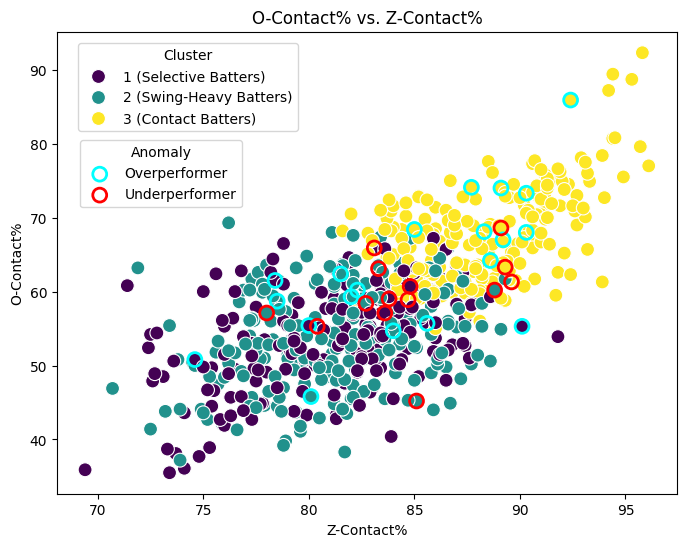

In [66]:
# Build scatterplot
plt.figure(figsize=(8, 6))
plot = sns.scatterplot(data=df, x='iz_contact_percent', y='oz_contact_percent', hue='cluster', palette='viridis', s=100)

# Build overlay scatterplot for highlighting overperforming anomalies
sns.scatterplot(
    data=df[df["overperforming_anomaly"] == True], 
    x='iz_contact_percent', y='oz_contact_percent',
    facecolor='none', edgecolor='aqua', linewidth=2, s=100, label="Overperformer"
)

# Build overlay scatterplot for highlighting underperforming anomalies
sns.scatterplot(
    data=df[df["underperforming_anomaly"] == True], 
    x='iz_contact_percent', y='oz_contact_percent',
    facecolor='none', edgecolor='red', linewidth=2, s=100, label="Underperformer"
)

# Find values needed for legends
num_clusters = df['cluster'].nunique()
handles, labels = plot.get_legend_handles_labels()

# Add cluster legend
cluster_legend = plot.legend(handles=handles[:num_clusters], labels=legend, 
                             title="Cluster", loc='upper right', bbox_to_anchor=(0.4, 0.99))
plot.add_artist(cluster_legend)

# Add anomaly legend
anomaly_legend = plot.legend(handles=handles[num_clusters:], labels=labels[num_clusters:], 
                             title="Anomaly", loc='upper right', bbox_to_anchor=(0.31, 0.78))

# Label and show scatterplot
plt.xlabel("Z-Contact%")
plt.ylabel("O-Contact%")
plt.title("O-Contact% vs. Z-Contact%")
plt.show()

Comparing Z-Contact% to O-Contact% reveals those who over- and underperformed. Overperformers had a more varied Z-Contact% than underperformers and held more extreme differences. Higher contact rates reveal more overperformers than underperformers, but beyond this, there is no clear pattern differentiating the two, aside from cluster denotements. Many overperformers appear alongside underperformers, and they remain very close together for the most part. This suggests that while the overall variance of wOBA can be affected by contact percentage, there is no other way to control this aspect of the game meaningfully.

### Results

Over- and underperformance is difficult to analyze because there are many reasons behind large discrepancies between wOBA and xwOBA. This difference concerns luck, so there is no concrete way to know or predict the discrepancies or their causes. The performance difference is the gap between what should happen based on how the ball is hit and what actually happens on the field. Players can get lucky or unlucky based on defensive plays/alignment, wind in the stadium affecting ball trajectory, stadium dimensions influencing the outcome of balls in play, and more. For these reasons, a massive performance difference is naturally unpredictable.

With these clarifications noted, Cluster 2 batters overperformed the least, due to bad luck but also low contact rates, driving strikeouts up and lowering wOBA as a result. Cluster 1 batters overperformed the most, since frequent contact rates influence positive luck. Underperformance was evenly spread out throughout. Contact driven batters lend themselves to higher wOBAs and are most consistent in this area, while aggressive ones are more volatile, because of the degrees to which they can excel and struggle.

While skill plays a role in examining over- and underperformance, most of it is random, and without further information, no solid takeaways or conclusions can be drawn from these anomalies alone.

## Structural vs. Performance Anomalies Analysis

The structural and performance anomalies found can now be analyzed simultaneously to identify additional connections and better understand their impacts on the domain as a whole.

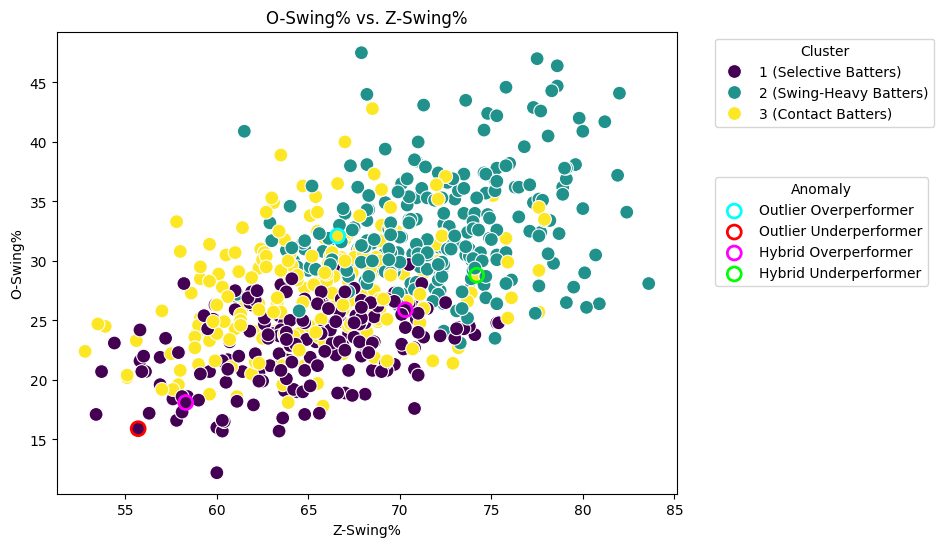

In [67]:
# Build scatterplot
plt.figure(figsize=(8, 6))
plot = sns.scatterplot(data=df, x='z_swing_percent', y='oz_swing_percent', hue='cluster', palette='viridis', s=100)

# Find points that are both outliers and overperformers
outlier_overperformer = (
    (df["outlier_anomaly"]) & (df["overperforming_anomaly"])
)

# Find points that are both outliers and underperformers
outlier_underperformer = (
    (df["outlier_anomaly"]) & (df["underperforming_anomaly"])
)

# Find points that are both hybrids and overperformers
hybrid_overperformer = (
    (df["hybrid_anomaly"]) & (df["overperforming_anomaly"])
)

# Find points that are both hybrids and underperformers
hybrid_underperformer = (
    (df["hybrid_anomaly"]) & (df["underperforming_anomaly"])
)

# Build overlay scatterplot for highlighting outlier overperformer anomalies
sns.scatterplot(
    data=df[outlier_overperformer], 
    x='z_swing_percent', y='oz_swing_percent',
    facecolor='none', edgecolor='aqua', linewidth=2, s=100, label="Outlier Overperformer"
)

# Build overlay scatterplot for highlighting outlier underperformer anomalies
sns.scatterplot(
    data=df[outlier_underperformer], 
    x='z_swing_percent', y='oz_swing_percent',
    facecolor='none', edgecolor='red', linewidth=2, s=100, label="Outlier Underperformer"
)

# Build overlay scatterplot for highlighting hybrid overperformer anomalies
sns.scatterplot(
    data=df[hybrid_overperformer], 
    x='z_swing_percent', y='oz_swing_percent',
    facecolor='none', edgecolor='#FF00FF', linewidth=2, s=100, label="Hybrid Overperformer"
)

# Build overlay scatterplot for highlighting hybrid underperformer anomalies
sns.scatterplot(
    data=df[hybrid_underperformer], 
    x='z_swing_percent', y='oz_swing_percent',
    facecolor='none', edgecolor='#00FF00', linewidth=2, s=100, label="Hybrid Underperformer"
)

# Find values needed for legends
num_clusters = df['cluster'].nunique()
handles, labels = plot.get_legend_handles_labels()

# Add anomaly legend
anomaly_legend = plot.legend(handles=handles[num_clusters:], labels=labels[num_clusters:], title="Anomaly", bbox_to_anchor=(1.05, 0.7), loc='upper left')
plot.add_artist(anomaly_legend)

# Add cluster legend
plot.legend(handles=handles[:num_clusters], labels=legend, title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

# Label and show scatterplot
plt.xlabel("Z-Swing%")
plt.ylabel("O-Swing%")
plt.title("O-Swing% vs. Z-Swing%")
plt.show()

The fact that only a handful of players have overlap between a structural and a performance anomaly underscores several points. Firstly, being unusual in the plate approach does not lead to an equally unusual performance result. While the two are not mutually exclusive, the instance of both occurring is very unlikely. This means that outliers still produce normal results despite their extreme profiles, and that hybrid players do not necessarily make them superior to outliers. Both of them have upsides and downsides that pull them back into a normalized performance level relative to other players. 

Based on the graph, it can also be inferred that performance anomalies come mainly from normal players with standard plate approaches within clusters, driving home the variance that that attribute possesses. Deviation in that area seems primarily factored by luck rather than anything else, including extreme approaches. Structural and performance anomalies are largely independent occurences, with very little relation between each other. The plate approach defines how a player plays, but not how well they perform relative to expectations. 

In [68]:
# Add all combined anomalies into a single dataframe
combined_anomales = [
    df[outlier_overperformer],
    df[outlier_underperformer],
    df[hybrid_overperformer],
    df[hybrid_underperformer]
]
combined_anomales = pd.concat(combined_anomales)
combined_anomales.head()

,"last_name, first_name",player_id,year,k_percent,bb_percent,woba,xwoba,z_swing_percent,oz_swing_percent,oz_contact_percent,...,swing_percent,perf_diff,cluster,centroid_distance,outlier_anomaly,hybrid_score,hybrid_anomaly,perf_zscore,overperforming_anomaly,underperforming_anomaly
667,"Wilson, Jacob",805779,2025,7.5,5.2,0.348,0.304,66.6,32.1,85.9,...,49.9,0.044,3,2.916870,True,2.233133,False,2.395923,True,False
595,"Soto, Juan",665742,2025,19.2,17.8,0.390,0.429,55.7,15.9,57.1,...,35.5,-0.039,1,3.087202,True,1.392898,False,-2.036814,False,True
452,"Varsho, Daulton",662139,2024,26.7,9.4,0.304,0.265,70.3,25.9,55.4,...,47.6,0.039,1,1.486968,False,0.140629,True,2.659131,True,False
611,"Friedl, TJ",670770,2025,16.8,11.8,0.333,0.303,58.3,18.1,55.3,...,39.2,0.030,1,2.666206,False,0.077311,True,2.117291,True,False
356,"Guerrero Jr., Vladimir",665489,2023,14.7,9.8,0.340,0.380,74.2,28.8,58.9,...,50.6,-0.040,3,2.050632,False,0.067480,True,-2.362749,False,True


Five instances of anomaly overlap imply this is a very rare scenario. They represent the intersection where noteworthy good/bad luck meets an extreme plate approach or an even balance of two. For example, 2025 Jacob Wilson was a Cluster 3 outlier, likely due to his very low K% and BB%, as well as his high O-Contact%. Additionally, he significantly overperformed by 0.044, suggesting he benefited from substantial luck. Each player in this small set is similar, assuming previously analyzed statistics, but either not living up to their expectations at all or far surpassing them.

## Anomaly Findings & Interpretation

### Results

Anomaly detection has yielded results that are beneficial to the final, originally proposed, discovery question. There are two categories, Structural and Performance anomalies, which hold anomalies related to plate approach strategies and performance results, respectively.

Structural anomalies hold players labeled as outliers and hybrid players. 

Outliers are players who deviate from the majority of their assigned cluster because, while they meet the conditions of their group, they do so to an extreme level. These are displays of plate approaches that are atypical because of how committed a player is to their strategy to the point that they go abnormally far with it; For instance, an aggressive Cluster 2 batter whose O-Swing% is well above the cluster's average, meaning their aggression is exhibited on an extreme level. Outliers were identified by calculating the Euclidean distances from each data point to the cluster centroid, then selecting the players with the top 5% highest distances for each cluster.

Hybrids are players who instead represent a mixture of two plate approaches, resulting in a diverging split between clusters. They are almost evenly distributed between two clusters, which means that during the clustering process, they were forced to be assigned to a single group, resulting in an inaccurate representation of them. For example, this can include a Cluster 1 batter who also had elevated contact rates similar to those of Cluster 3 batters. Hybrid players were identified by computing the Euclidean distance between the cluster centroids of the two closest clusters for each player and then taking the difference between them. The lowest 5% of resulting differences were assumed to be anomalies.

These structural anomalies were nearly equally distributed across the clusters. No cluster was found to be most susceptible to either type of anomaly in this category. They simply outline the two opposite sides of a single cluster. Some players fit almost too well into their group, while others barely fit because of their split between two groups.

Performance anomalies label players as overperformers or underperformers based on their xwOBA and true wOBA. The differences between these two attributes are used to identify these anomalies, which are then converted to Z-scores for each cluster to find which differences are most unusual. Values more than 2 standard deviations from the mean were identified as anomalies, with positive values indicating overperformance and negative values indicating underperformance. Because xwOBA is defined as what should happen based on the quality of contact made with a ball, while wOBA is judged purely on what actually happens on the field, significant differences between the two can be caused by various reasons. Luck on the field becomes a big factor, as do environmental concerns such as weather and stadium nuances. Additionally, the cluster distributions were quite unbalanced; Cluster 2, swing-heavy batters, had the fewest overperformers (4 players), while Cluster 3, contact batters, had the most (10 players).

### Interpretative Findings

Broadly, each anomaly indicates key findings about MLB batters. Most notably, the fact that very little of these anomalies overlap suggests that they are not very connected. Unnatural plate approaches still mainly lead to normal performance results, while standard plate approaches can produce unexpected performance results at random. Structural and performance anomalies remain independent and standalone from each other.

Identifying outlier anomalies is meaningful because it further clarifies a player's hitting type, going beyond the original clustering assignments. It is understood that these batters are outliers within their cluster, warranting investigation because they suggest that clusters capture only general tendencies of players, whereas these players span a wide spectrum of plate approaches. Exaggerated, over-optimized strategies lead to these unusual profiles because those players are more constructed as one-dimensional or specialized hitters with pronounced strengths and weaknesses. These outliers can also represent the boundaries of each cluster's identity, serving as reference points for the cluster's range.

Hybrid anomalies are similar in their ability to clarify hitter characteristics. Instead of being defined solely by a single plate approach, they represent a blend of two. These players flag the limitations of clustering and the K-Means process — they impose hard boundaries and force clustering assignments in the face of ambiguity. Hybrid players display multidimensional skill sets, challenging the assumption that all players fit neatly into a single plate approach category. Therefore, clustering provides useful abstractions, but still holds overlaps that these players exploit.

Structural anomalies differentiate a batter's profiling, not their overall skill or performance from a results perspective, which is what performance anomalies highlight.

Major performance differences are not mainly determined by plate approaches; rather, they mainly highlight luck and the context of external factors in outcomes. Players within the same cluster, even with very similar underlying statistics, can have wildly varying results, reinforcing this variability. The unbalanced nature of overperforming players, however, suggests that a controllable factor is at play in their occurrences. The biggest differentiator between the leading cluster in this area, Cluster 3, and the worst-performing one, Cluster 2, is contact. More contact increases wOBA potential, while less of it stagnates it. This is not the sole controller of wOBA because of the significant variance it exhibits and can be influenced by, but it is the factor within a batter's control at all times. There is higher outcome volatility tied to balls in play, so Cluster 3 is more susceptible to favorable variance.

Meanwhile, underperformers reflect unrealized potential and may signal future upward regression as opposed to overperformers who experience short-term success beyond expected metrics. The imbalance across clusters suggests that certain approaches are more prone to deviation than others, and that overall baseball performance is influenced by a mix of skill and randomness that cannot be predicted, rather than solely by plate approaches.

### Real World Applications

The identified anomaly points add further value beyond clustering to real-world scenarios within the MLB domain. Structural anomalies are most useful for different purposes. Hybrid players can be used much more strategically in games thanks to their enhanced versatility. Their mixed approach makes them more adaptable in different game situations. Outliers, on the other hand, are much more predictable and are players that can be used when a certain result is desired. This knowledge can be applied to potential pinch-hit situations as well as substitutions according to varying in-game differences.

Performance anomalies are also useful, but in much different ways. Instead of guiding the evaluation of a player's plate approach and in-game use, these anomalies provide context for how a player is performing. This allows each team to see whether a player is due for positive or negative regression back toward their expected statistics. This helps prevent over- or under-valuing any player prematurely, directing contract negotiations, roster decisions, and lineup construction.